In [33]:
import sys
sys.path.append("/Users/27171653/Desktop/PhD/Specular-Highlights/sh_models")
from pipeline import dhl_generator as dhl_gen
from pipeline import PSDloader as psd_loader
from sh_models import highlight_detector as hd
from sh_models import pconvAE as pc_hr
import matplotlib.pyplot as plt
import torch
from typing import Tuple, Optional


## Generate Highlight  mask for tests 

torch.Size([2, 1, 512, 768]) 0.0 1.0


(np.float64(-0.5), np.float64(767.5), np.float64(511.5), np.float64(-0.5))

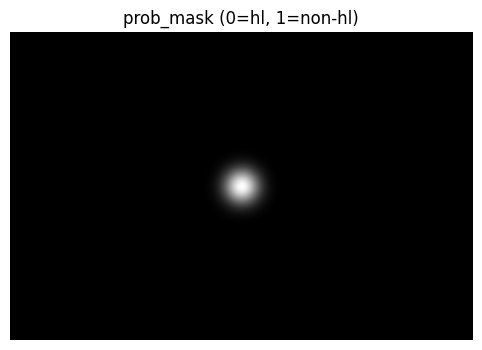

In [34]:
def generate_radial_highlight_prob_mask(
    B: int,
    H: int,
    W: int,
    centre: Optional[Tuple[int, int]] = None,
    radius: float = 20.0,
    softness: float = 0.35,
    background: float = 1.0,
    min_centre: float = 0.0,
    device: Optional[torch.device] = None,
    dtype: torch.dtype = torch.float32,
) -> torch.Tensor:
    """
    Returns prob_mask of shape (B,1,H,W) with:
      - clean background: prob=background (default 1.0 = non-highlight)
      - one circular highlight: prob decreases towards centre, minimum at centre (default 0.0)

    Convention: 0 = highlight, 1 = non-highlight.

    radius: controls highlight size.
    softness: controls edge softness; smaller -> sharper edge, larger -> smoother falloff.
    """
    if centre is None:
        cy, cx = H // 2, W // 2
    else:
        cy, cx = centre

    device = device if device is not None else torch.device("cpu")

    yy, xx = torch.meshgrid(
        torch.arange(H, device=device, dtype=dtype),
        torch.arange(W, device=device, dtype=dtype),
        indexing="ij",
    )

    # Normalised radial distance: d=0 at centre, d=1 at radius
    d = torch.sqrt((yy - cy) ** 2 + (xx - cx) ** 2) / max(radius, 1e-6)

    # Smooth radial profile: ~1 at centre, ~0 outside radius
    # Using a Gaussian-like falloff; softness sets how quickly it decays.
    # At d=0 -> profile=1, as d increases -> profile -> 0
    profile = torch.exp(-(d ** 2) / max(softness ** 2, 1e-6))

    # Make background exactly 'background' by zeroing profile far away
    # (optional but keeps it clean)
    profile = torch.where(d <= 1.0, profile, torch.zeros_like(profile))

    # Map profile to prob space: centre -> min_centre, outside -> background
    # prob = background - profile*(background - min_centre)
    prob_2d = background - profile * (background - min_centre)

    prob_mask = prob_2d.unsqueeze(0).unsqueeze(0).repeat(B, 1, 1, 1)
    return prob_mask


B, H, W = 2, 512, 768
hl = generate_radial_highlight_prob_mask(B, H, W, radius=70, softness=0.4)
print(hl.shape, hl.min().item(), hl.max().item())
h = hl[1, 0].detach().cpu()

fig, axs = plt.subplots(1, 1, figsize=(16, 4))

axs.imshow(h,cmap='gray_r', vmin=0, vmax=1)
axs.set_title("prob_mask (0=hl, 1=non-hl)")
axs.axis("off") 

## Test Highlight Detector model

In [35]:
def test_detector():
    # Testing the highlight detector
    print("Testing the highlight detector ...")
    model = hd.Detector(in_channels=3)
    x = torch.randn(6, 3, 256, 256)
    m_soft = model(x)
    print(f"Input shape: {x.shape}")
    print(f"M_soft shape: {m_soft.shape}")
    print(f"M_soft range: [{m_soft.min():.4f}, {m_soft.max():.4f}]")
    return x, m_soft

In [36]:
x, m_soft = test_detector()

Testing the highlight detector ...
Input shape: torch.Size([6, 3, 256, 256])
M_soft shape: torch.Size([6, 1, 256, 256])
M_soft range: [0.0000, 1.0000]


## Test Dynamic Highlight Generator

In [37]:

def testdhlgenerator( hl = None, blurstrength: float = 1.0, threshold_method: str= "quantile",q: float = 0.10, aoi_fraction: float = 0.5):
    torch.manual_seed(0)

    # ---- create a fake prob_mask (0=highlight, 1=non-highlight) ----
    B, H, W = 2, 128, 128
    prob_mask = torch.rand(B, 1, H, W)

    # Inject a "highlight blob" (low values) so we can see thresholding work
    yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing="ij")
    centre = (H // 2, W // 2)
    r2 = (yy - centre[0])**2 + (xx - centre[1])**2
    blob = (r2 < (20**2)).float()  # circle radius 20

    prob_mask[0, 0] = torch.where(blob.bool(), prob_mask[0, 0] * 0.05, prob_mask[0, 0])  # stronger highlights
    prob_mask[1, 0] = torch.where(blob.bool(), prob_mask[1, 0] * 0.20, prob_mask[1, 0])  # weaker highlights

    if hl is not None:
        prob_mask = hl
        B,C, H, W = hl.shape



    # ---- create an AoI mask (only allow thresholding in the left half) ----
    
    aoi = torch.zeros(B, 1, H, W, dtype=torch.bool)
    aoi[:, :, :, : int(W * aoi_fraction)] = True  # left half is interest

    # ---- test threshold calculation ----
    p_no_aoi = dhl_gen.calculate_threshold(prob_mask= prob_mask, method =   threshold_method, q=q, aoi=None)   # (B,)
    p_with_aoi = dhl_gen.calculate_threshold(prob_mask=prob_mask, method=threshold_method, q=q, aoi=aoi)  # (B,)

    print("prob_mask shape:", tuple(prob_mask.shape), "q:", q)
    print("AoI shape:", tuple(aoi.shape), "AoI true %:", float(aoi.float().mean() * 100), "%")
    print("p (no AoI):   ", p_no_aoi.tolist())
    print("p (with AoI): ", p_with_aoi.tolist())

    # ---- generate dynamic highlight masks ----
    soft_no_aoi = dhl_gen.generate_dynamic_highlight_mask(prob_mask, threshold_method=threshold_method, q=q, aoi=None, kernel_size=5, sigma=blurstrength)
    soft_with_aoi = dhl_gen.generate_dynamic_highlight_mask(prob_mask, threshold_method=threshold_method, q=q, aoi=aoi, kernel_size=5, sigma=blurstrength)

    # ---- sanity checks ----
    print("\nsoft_no_aoi shape:", tuple(soft_no_aoi.shape),
          "range:", (float(soft_no_aoi.min()), float(soft_no_aoi.max())))
    print("soft_with_aoi shape:", tuple(soft_with_aoi.shape),
          "range:", (float(soft_with_aoi.min()), float(soft_with_aoi.max())))

    # ---- show how much got muted to 1 before blur (optional quick check) ----
    muted_no_aoi = dhl_gen.ProbMaskThresholdOperator(p=p_no_aoi, op_above=dhl_gen.set_to_one, op_below=dhl_gen.identity)(prob_mask)
    muted_with_aoi = dhl_gen.ProbMaskThresholdOperator(p=p_with_aoi, op_above=dhl_gen.set_to_one, op_below=dhl_gen.identity)(prob_mask)

    frac_one_no_aoi = float((muted_no_aoi == 1).float().mean())
    frac_one_with_aoi = float((muted_with_aoi == 1).float().mean())

    print("\nFraction of pixels set to 1 (muted) - no AoI:  ", frac_one_no_aoi)
    print("Fraction of pixels set to 1 (muted) - with AoI:", frac_one_with_aoi)

    return soft_no_aoi, soft_with_aoi, aoi, prob_mask



prob_mask shape: (2, 1, 512, 768) q: 0.7
AoI shape: (2, 1, 512, 768) AoI true %: 69.921875 %
p (no AoI):    [0.708984375, 0.708984375]
p (with AoI):  [0.708984375, 0.708984375]

soft_no_aoi shape: (2, 1, 512, 768) range: (0.0005837332573719323, 1.0)
soft_with_aoi shape: (2, 1, 512, 768) range: (0.0005837332573719323, 1.0)

Fraction of pixels set to 1 (muted) - no AoI:   0.9922663569450378
Fraction of pixels set to 1 (muted) - with AoI: 0.9922663569450378


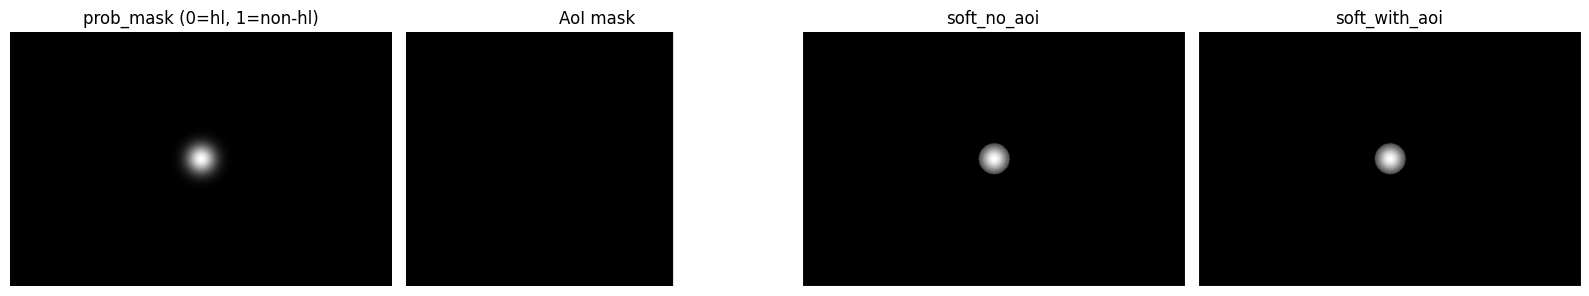

In [38]:
soft_no_aoi, soft_with_aoi, aoi, prob_mask = testdhlgenerator(hl =hl, blurstrength=0.51, threshold_method="otsu", aoi_fraction=0.7, q = 0.7)  # or however you call it

def show_maps(b=1):
    # pull out (H,W) arrays
    pm = prob_mask[b, 0].detach().cpu()
    sn = soft_no_aoi[b, 0].detach().cpu()
    sw = soft_with_aoi[b, 0].detach().cpu()
    mi = aoi[b, 0].detach().cpu() if aoi.ndim == 4 else aoi[b].detach().cpu()

    fig, axs = plt.subplots(1, 4, figsize=(16, 4))

    axs[0].imshow(pm,cmap='gray_r', vmin=0, vmax=1)
    axs[0].set_title("prob_mask (0=hl, 1=non-hl)")
    axs[0].axis("off")

    axs[1].imshow(mi,cmap='gray_r', vmin=0, vmax=1)
    axs[1].set_title("AoI mask")
    axs[1].axis("off")

    axs[2].imshow(sn, cmap='gray_r', vmin=0, vmax=1)
    axs[2].set_title("soft_no_aoi")
    axs[2].axis("off")

    axs[3].imshow(sw, cmap='gray_r', vmin=0, vmax=1)
    axs[3].set_title("soft_with_aoi")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()

show_maps(b=0)

## Test highlight removal AE

In [39]:
def test_highlight_removal_autoencoder(
    soft_mask=None,
    depth: int = 4,
    base_features: int = 64,
    max_features: int = 512,
    bottleneck_blocks: int = 2,
    device=None,
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    model = pc_hr.HighlightRemovalAutoencoder(
        in_channels=3,
        out_channels=1,
        base_features=base_features,
        depth=depth,
        max_features=max_features,
        bottleneck_blocks=bottleneck_blocks,
    ).to(device)

    if soft_mask is None:
        x = torch.rand(B, 3, H, W, device=device)
        soft_mask = torch.rand(B, 1, H, W, device=device)
    else:
        soft_mask = soft_mask.to(device).float()
        if soft_mask.dim() == 3:
            soft_mask = soft_mask.unsqueeze(1)
        B, _, H, W = soft_mask.shape
        x = torch.rand(B, 3, H, W, device=device)

    y = model(x, soft_mask)

    print("Depth :", depth)
    print("Input :", x.shape)
    print("Mask  :", soft_mask.shape)
    print("Output:", y.shape)

    return model, x, soft_mask, y



Depth : 4
Input : torch.Size([2, 3, 512, 768])
Mask  : torch.Size([2, 1, 512, 768])
Output: torch.Size([2, 1, 512, 768])


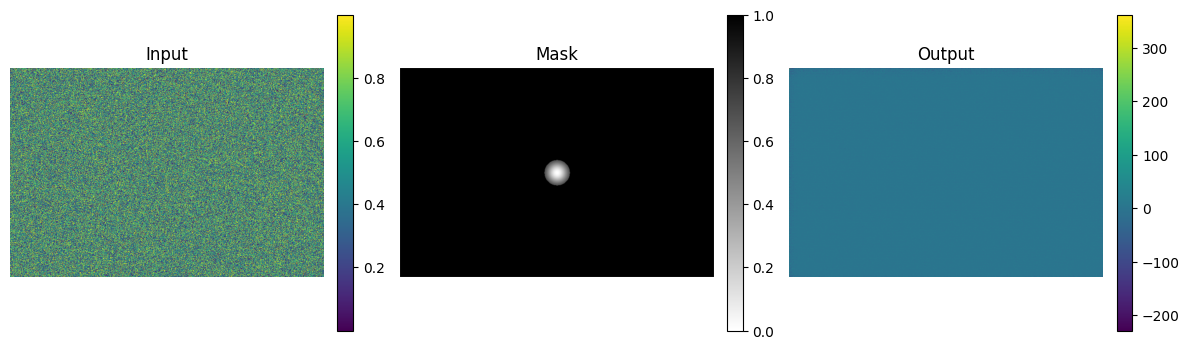

In [40]:
model, x, soft_mask, y = test_highlight_removal_autoencoder(soft_mask=soft_with_aoi, depth=4)

def plot_input_mask_output(x, soft_mask, y, batch_idx=0, cmap="gray_r"):
    
    x_img = x[batch_idx, 0].detach().cpu()
    m_img = soft_mask[batch_idx, 0].detach().cpu()
    y_img = y[batch_idx, 0].detach().cpu()

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))

    im0 = axs[0].imshow(x_img)
    axs[0].set_title("Input")
    axs[0].axis("off")
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

    im1 = axs[1].imshow(m_img, cmap=cmap, vmin=0, vmax=1)
    axs[1].set_title("Mask")
    axs[1].axis("off")
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

    im2 = axs[2].imshow(y_img)
    axs[2].set_title("Output")
    axs[2].axis("off")
    plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    
plot_input_mask_output(x, soft_mask, y, batch_idx=0)

## Test Mask Extractor

In [41]:
clean_path = "/Users/27171653/Desktop/PhD/PSD_Dataset/PSD_Dataset/PSD_Train/PSD_Train_diffuse/filtered-0001.png"
hl_path = "/Users/27171653/Desktop/PhD/PSD_Dataset/PSD_Dataset/PSD_Train/PSD_Train_specular/filtered-0001.png"


In [42]:
import cv2
import numpy as np


def extract_highlight_mask_from_paths(
    img_hl_path,
    img_clean_path,
    soft=False,
    threshold_method="fixed",
    threshold=0.05,
    q=0.99,
    kernel_size=3,
    soft_gamma=0.5,
):
    img_hl = cv2.imread(img_hl_path, cv2.IMREAD_COLOR)
    img_clean = cv2.imread(img_clean_path, cv2.IMREAD_COLOR)

    if img_hl is None:
        raise FileNotFoundError(f"Could not read highlighted image: {img_hl_path}")
    if img_clean is None:
        raise FileNotFoundError(f"Could not read clean image: {img_clean_path}")

    img_hl = cv2.cvtColor(img_hl, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img_clean = cv2.cvtColor(img_clean, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    if img_hl.shape != img_clean.shape:
        raise ValueError(
            f"Image shapes must match, got {img_hl.shape} and {img_clean.shape}"
        )

    # positive difference only
    diff = np.clip(img_hl - img_clean, 0.0, None)
    diff_map = diff.mean(axis=2)

    if soft:
        soft_mask = diff_map / (diff_map.max() + 1e-8)
        soft_mask = np.power(soft_mask, soft_gamma)
        soft_mask = 1.0 - soft_mask   # 0 = highlight, 1 = non-highlight
        soft_mask = np.clip(soft_mask, 0.0, 1.0)
        return soft_mask.astype(np.float32), diff_map

    if threshold_method == "fixed":
        t = threshold
    elif threshold_method == "quantile":
        t = np.quantile(diff_map, q)
    elif threshold_method == "otsu":
        dm = diff_map / (diff_map.max() + 1e-8)
        dm_u8 = (dm * 255).astype(np.uint8)
        t_u8, _ = cv2.threshold(dm_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        t = t_u8 / 255.0
    else:
        raise ValueError("threshold_method must be 'fixed', 'quantile', or 'otsu'")

    mask = (diff_map > t).astype(np.uint8)
    mask = 1 - mask   # 0 = highlight, 1 = non-highlight

    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask.astype(np.float32), diff_map

In [43]:
mask, diff_map = extract_highlight_mask_from_paths(
    img_hl_path=hl_path,
    img_clean_path=clean_path,
    threshold_method="otsu"
)

In [44]:
mask, diff_map = extract_highlight_mask_from_paths(
    img_hl_path=hl_path,
    img_clean_path=clean_path,
    threshold_method="quantile",
    q=0.99
)

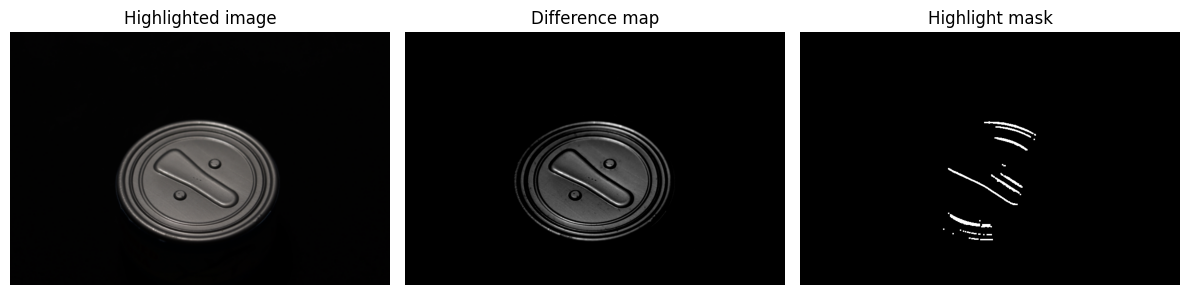

In [45]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(cv2.imread(hl_path), cv2.COLOR_BGR2RGB))
plt.title("Highlighted image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(diff_map, cmap="gray")
plt.title("Difference map")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask, cmap="gray_r")
plt.title("Highlight mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
mask.shape

(512, 768)

## Test dataloader 

In [47]:
import random
import matplotlib.pyplot as plt
import torch


def show_5_random_samples(dataset, seed=None, show_thresholded=True):
    if seed is not None:
        random.seed(seed)

    n = min(5, len(dataset))
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(n, 4 if show_thresholded else 3, figsize=(16, 3 * n))

    if n == 1:
        axes = [axes]

    for row, idx in enumerate(indices):
        sample = dataset[idx]

        img = sample["input"].permute(1, 2, 0).cpu()
        target = sample["target"].permute(1, 2, 0).cpu()
        soft_mask = sample["soft_mask"][0].cpu()
        dhlmask = sample["mask"][0].cpu()

        

        ax = axes[row]

        ax[0].imshow(img)
        ax[0].set_title(f"Specular\n{sample['name']}")
        ax[0].axis("off")

        ax[1].imshow(target)
        ax[1].set_title("Diffuse")
        ax[1].axis("off")

        ax[2].imshow(soft_mask, cmap="gray_r", vmin=0, vmax=1)
        ax[2].set_title("Soft mask\n0=hl, 1=non-hl")
        ax[2].axis("off")

        if show_thresholded:
            ax[3].imshow(dhlmask, cmap="gray_r", vmin=0, vmax=1)
            ax[3].set_title("Dynamic Highlight mask")
            ax[3].axis("off")

    plt.tight_layout()
    plt.show()

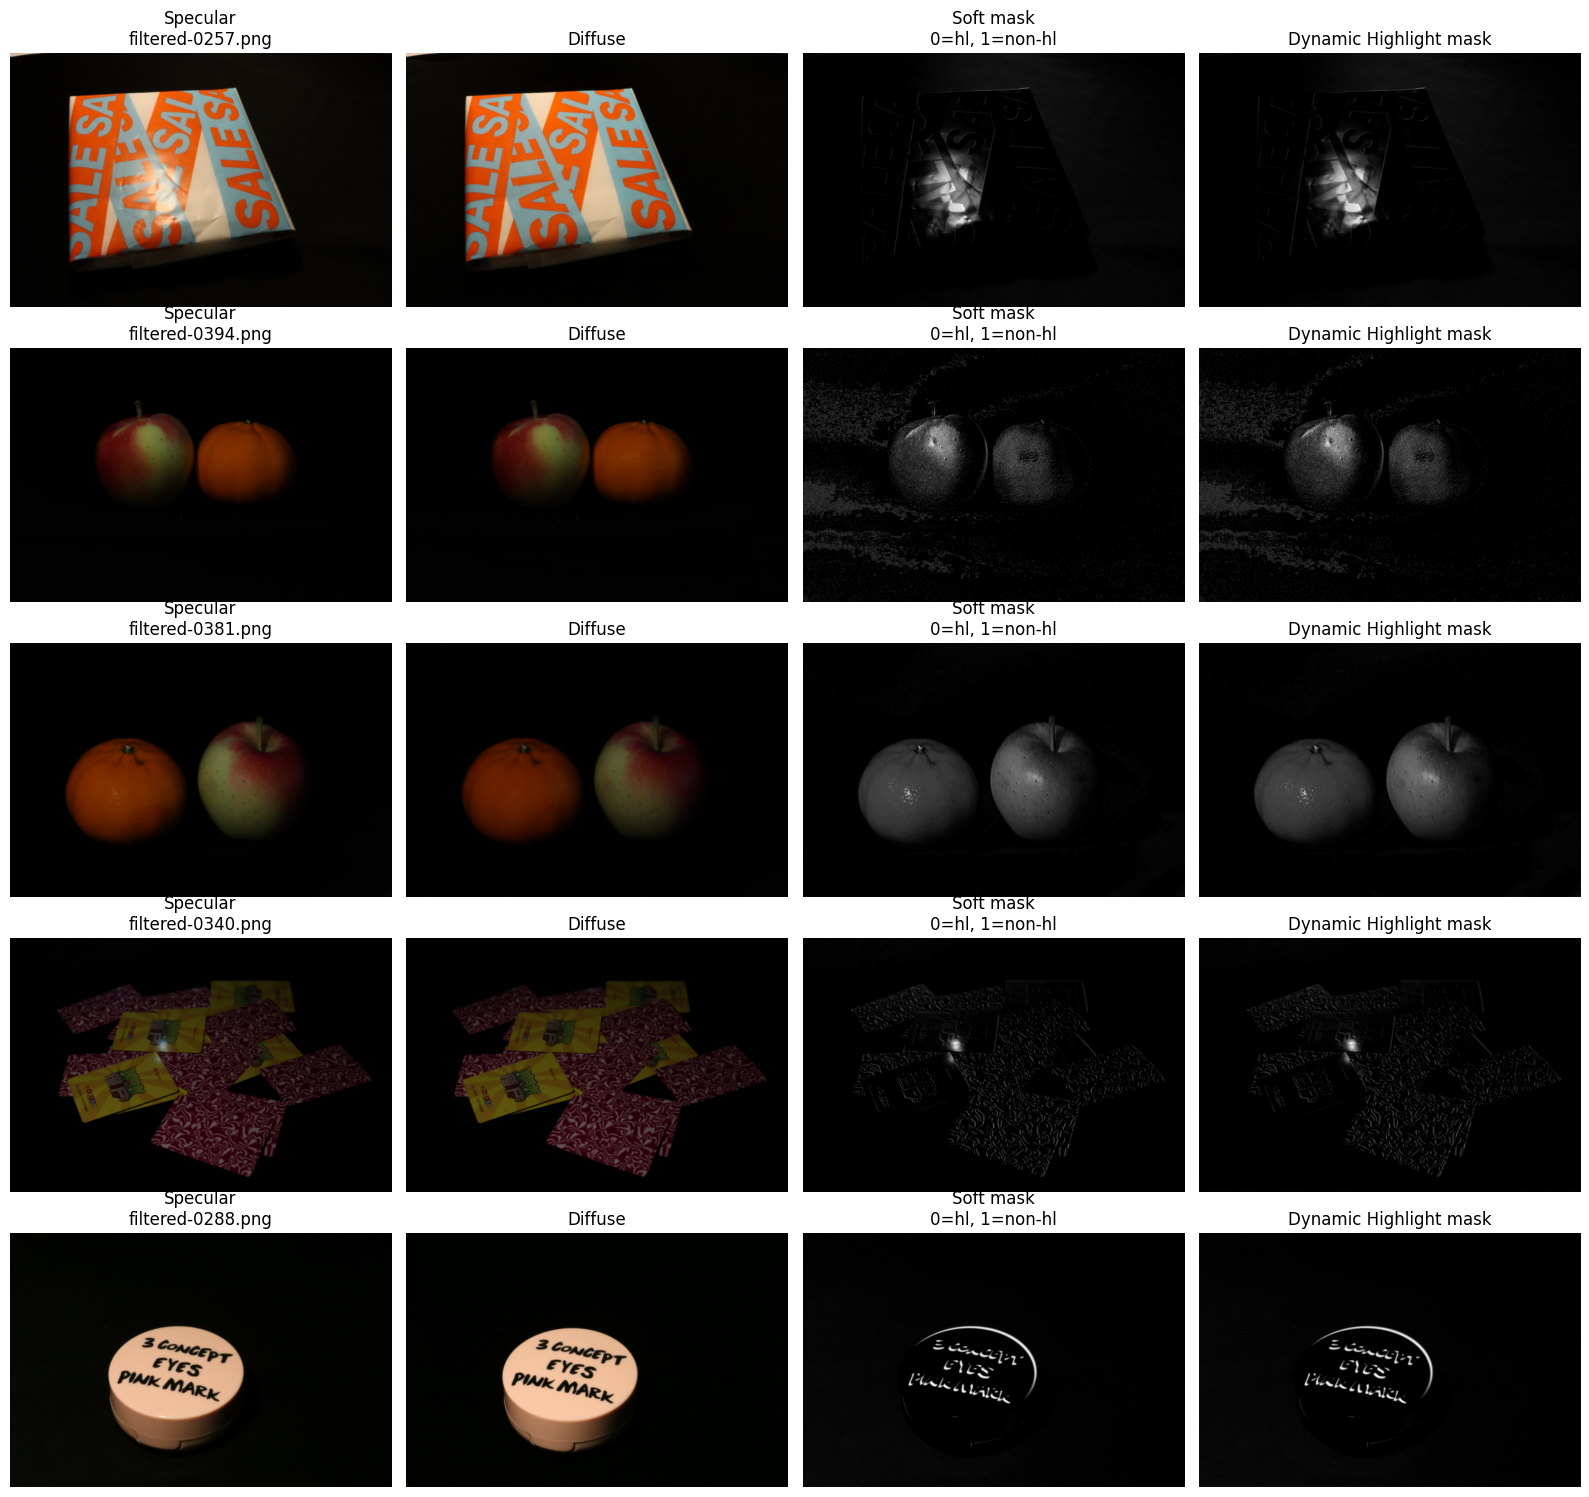

In [48]:
diffuse_images = "/Users/27171653/Desktop/PhD/PSD_Dataset/PSD_Dataset/PSD_Train/PSD_Train_diffuse"
specular_images = "/Users/27171653/Desktop/PhD/PSD_Dataset/PSD_Dataset/PSD_Train/PSD_Train_specular"

dataset, loader = psd_loader.make_psd_dataloader(
    diffuse_dir=diffuse_images,
    specular_dir=specular_images,
    batch_size=4,
    soft_gamma=1.0,
    threshold_method="quantile",
    threshold=0.9,
)

show_5_random_samples(dataset, show_thresholded=True)

In [49]:
import random
import matplotlib.pyplot as plt
import torch


def show_dataset_samples(
    dataset,
    indices=None,
    n_random=None,
    seed=None,
    show_thresholded=True,
):
    """
    Plot chosen samples from the dataset.

    Parameters
    ----------
    dataset : Dataset
        Dataset where each sample contains:
            "input"      : [3,H,W]
            "target"     : [3,H,W]
            "soft_mask"  : [1,H,W]
            "mask"       : [1,H,W]   (optional if show_thresholded=False)

    indices : int or list[int] or tuple[int], optional
        1-based dataset indices to plot.
        Example:
            indices=1
            indices=[1, 5, 10]

    n_random : int, optional
        Number of random samples to plot using 1-based display logic.

    seed : int, optional
        Random seed for reproducible random sampling.

    show_thresholded : bool, default=True
        Whether to also show sample["mask"].

    Notes
    -----
    Uses 1-based indexing for the user:
        1 means dataset[0]
        len(dataset) means dataset[len(dataset)-1]
    """
    if len(dataset) == 0:
        raise ValueError("Dataset is empty.")

    if indices is None and n_random is None:
        indices = [1]

    if seed is not None:
        random.seed(seed)

    if indices is not None:
        if isinstance(indices, int):
            indices = [indices]
        else:
            indices = list(indices)

        for idx in indices:
            if idx < 1 or idx > len(dataset):
                raise IndexError(
                    f"Index {idx} is out of range for dataset of length {len(dataset)}. "
                    f"Valid range is 1 to {len(dataset)}."
                )

        # Convert 1-based to 0-based
        zero_based_indices = [idx - 1 for idx in indices]

    else:
        n_random = min(n_random, len(dataset))
        zero_based_indices = random.sample(range(len(dataset)), n_random)

    n = len(zero_based_indices)
    ncols = 4 if show_thresholded else 3

    fig, axes = plt.subplots(n, ncols, figsize=(4 * ncols, 3 * n))

    if n == 1:
        axes = [axes]

    for row, ds_idx in enumerate(zero_based_indices):
        sample = dataset[ds_idx]

        img = sample["input"].detach().cpu().permute(1, 2, 0)
        target = sample["target"].detach().cpu().permute(1, 2, 0)
        soft_mask = sample["soft_mask"].detach().cpu()[0]

        if "name" in sample:
            name_text = sample["name"]
        else:
            name_text = f"item {ds_idx + 1}"

        ax = axes[row]

        ax[0].imshow(img)
        ax[0].set_title(f"Specular\n{name_text}")
        ax[0].axis("off")

        ax[1].imshow(target)
        ax[1].set_title("Diffuse")
        ax[1].axis("off")

        ax[2].imshow(soft_mask, cmap="gray_r", vmin=0, vmax=1)
        ax[2].set_title("Soft mask\n0=hl, 1=non-hl")
        ax[2].axis("off")

        if show_thresholded:
            if "mask" not in sample:
                raise KeyError("Sample does not contain 'mask' but show_thresholded=True.")
            dhlmask = sample["mask"].detach().cpu()[0]
            ax[3].imshow(dhlmask, cmap="gray_r", vmin=0, vmax=1)
            ax[3].set_title("Dynamic Highlight mask")
            ax[3].axis("off")

    plt.tight_layout()
    plt.show()

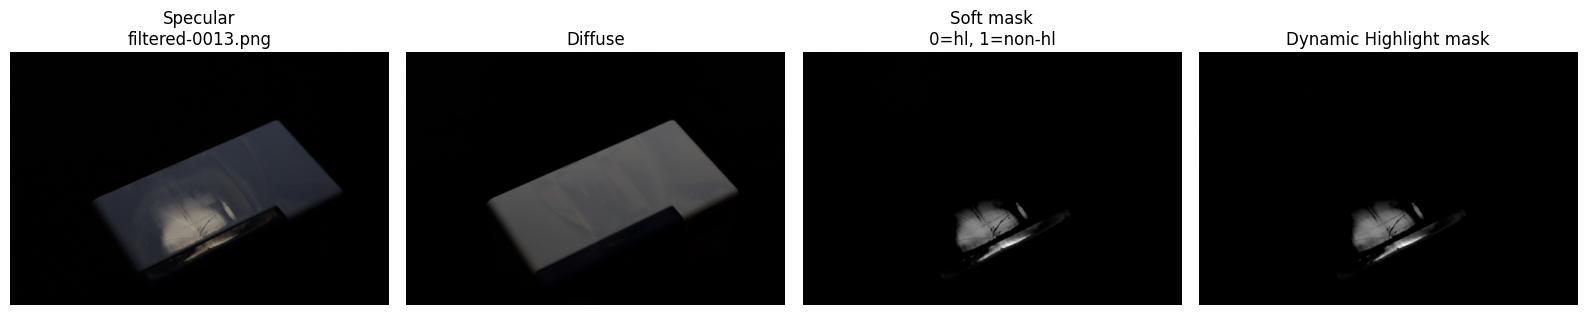

In [50]:
show_dataset_samples(dataset, indices=13)

## 

## Test Sample and Lighting generation

In [51]:
from pathlib import Path
from pipeline import buildscene as scene_builder
from pipeline import generatem3sample as m3_gen


In [52]:
PROJECT_ROOT = Path("/Users/27171653/Desktop/PhD/Specular-Highlights")
RENDERED_OBJECTS = ["teapot", "turbine", "can", "case", "guide_vane"]

def load_rendered_object_dataset(model_name, batch_size=4, threshold=0.9, soft_gamma=1.0):
    diffuse_dir = PROJECT_ROOT / "data" / "train" / model_name / "diffuse"
    specular_dir = PROJECT_ROOT / "data" / "train" / model_name / "glossy"

    dataset, loader = psd_loader.make_psd_dataloader(
        diffuse_dir=str(diffuse_dir),
        specular_dir=str(specular_dir),
        batch_size=batch_size,
        soft_gamma=soft_gamma,
        threshold_method="quantile",
        threshold=threshold,
    )

    return dataset, loader

def visualize_rendered_object(model_name, seed=0, show_thresholded=True):
    dataset, loader = load_rendered_object_dataset(model_name)
    print(f"=== {model_name} ({len(dataset)} samples) ===")
    show_5_random_samples(dataset, seed=seed, show_thresholded=show_thresholded)
    return dataset, loader


In [53]:
teapot = "/Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/teapot/teapot.ply"
template_xml = "/Users/27171653/Desktop/PhD/Specular-Highlights/data/scene.xml"
generated_dir = "/Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/teapot/scenes/"

teapot_diffuse_scene_path, scene_info =  scene_builder.buildscene(
    objectpath=teapot,
    material_mode="diffuse",
    template_xml_path=template_xml,
    output_dir=generated_dir,
)

teapot_glossy_scene_path, _ = scene_builder.buildscene(
    objectpath=teapot,
    material_mode="glossy",
    template_xml_path=template_xml,
    output_dir=generated_dir,
)

print("Diffuse scene:", teapot_diffuse_scene_path)
print("Glossy scene :", teapot_glossy_scene_path)
print("Scene info:")
scene_info

Diffuse scene: /Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/teapot/scenes/teapot_diffuse.xml
Glossy scene : /Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/teapot/scenes/teapot_glossy.xml
Scene info:


{'objectpath': '/Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/teapot/teapot.ply',
 'saved_scene_path': '/Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/teapot/scenes/teapot_diffuse.xml',
 'material_mode': 'diffuse',
 'mesh_bounds_min': [-3.0, -2.0, 0.0],
 'mesh_bounds_max': [3.4296300411224365, 2.0, 3.1500000953674316],
 'centre': [0.21481502056121826, 0.0, 1.5750000476837158],
 'extent': [6.4296300411224365, 4.0, 3.1500000953674316],
 'size': 6.4296300411224365,
 'n_views': 10,
 'n_lights': 8,
 'ring_tilt_deg': 0.0,
 'up': [0.0, 0.0, 1.0],
 'target': [0.21481502056121826, 0.0, 1.890000057220459],
 'orbit_radius': 25.718520164489746,
 'orbit_height': 11.21944510936737,
 'ring_radius': 0.9644445061683654,
 'ring_forward': 0.5143704032897949,
 'cam_target_distance': 27.358377591375813,
 'light_target_distance': 26.861326756500546,
 'spp': 256,
 'res': 256,
 'ring_intensity': 39.590171474320556,
 'ring_intensity_base': 40.0,
 'auto_scale_ring_intensity': True,


In [54]:
m3_gen.render_dataset_from_sceneinfo(
    model="teapot",
    diffuse_scene_path=teapot_diffuse_scene_path,
    glossy_scene_path=teapot_glossy_scene_path,
    scene_info=scene_info,
)

Rendered position_00 | diffuse + glossy
Rendered position_01 | diffuse + glossy
Rendered position_02 | diffuse + glossy
Rendered position_03 | diffuse + glossy
Rendered position_04 | diffuse + glossy
Rendered position_05 | diffuse + glossy
Rendered position_06 | diffuse + glossy
Rendered position_07 | diffuse + glossy
Rendered position_08 | diffuse + glossy
Rendered position_09 | diffuse + glossy
Done. Rendered 10 paired positions.


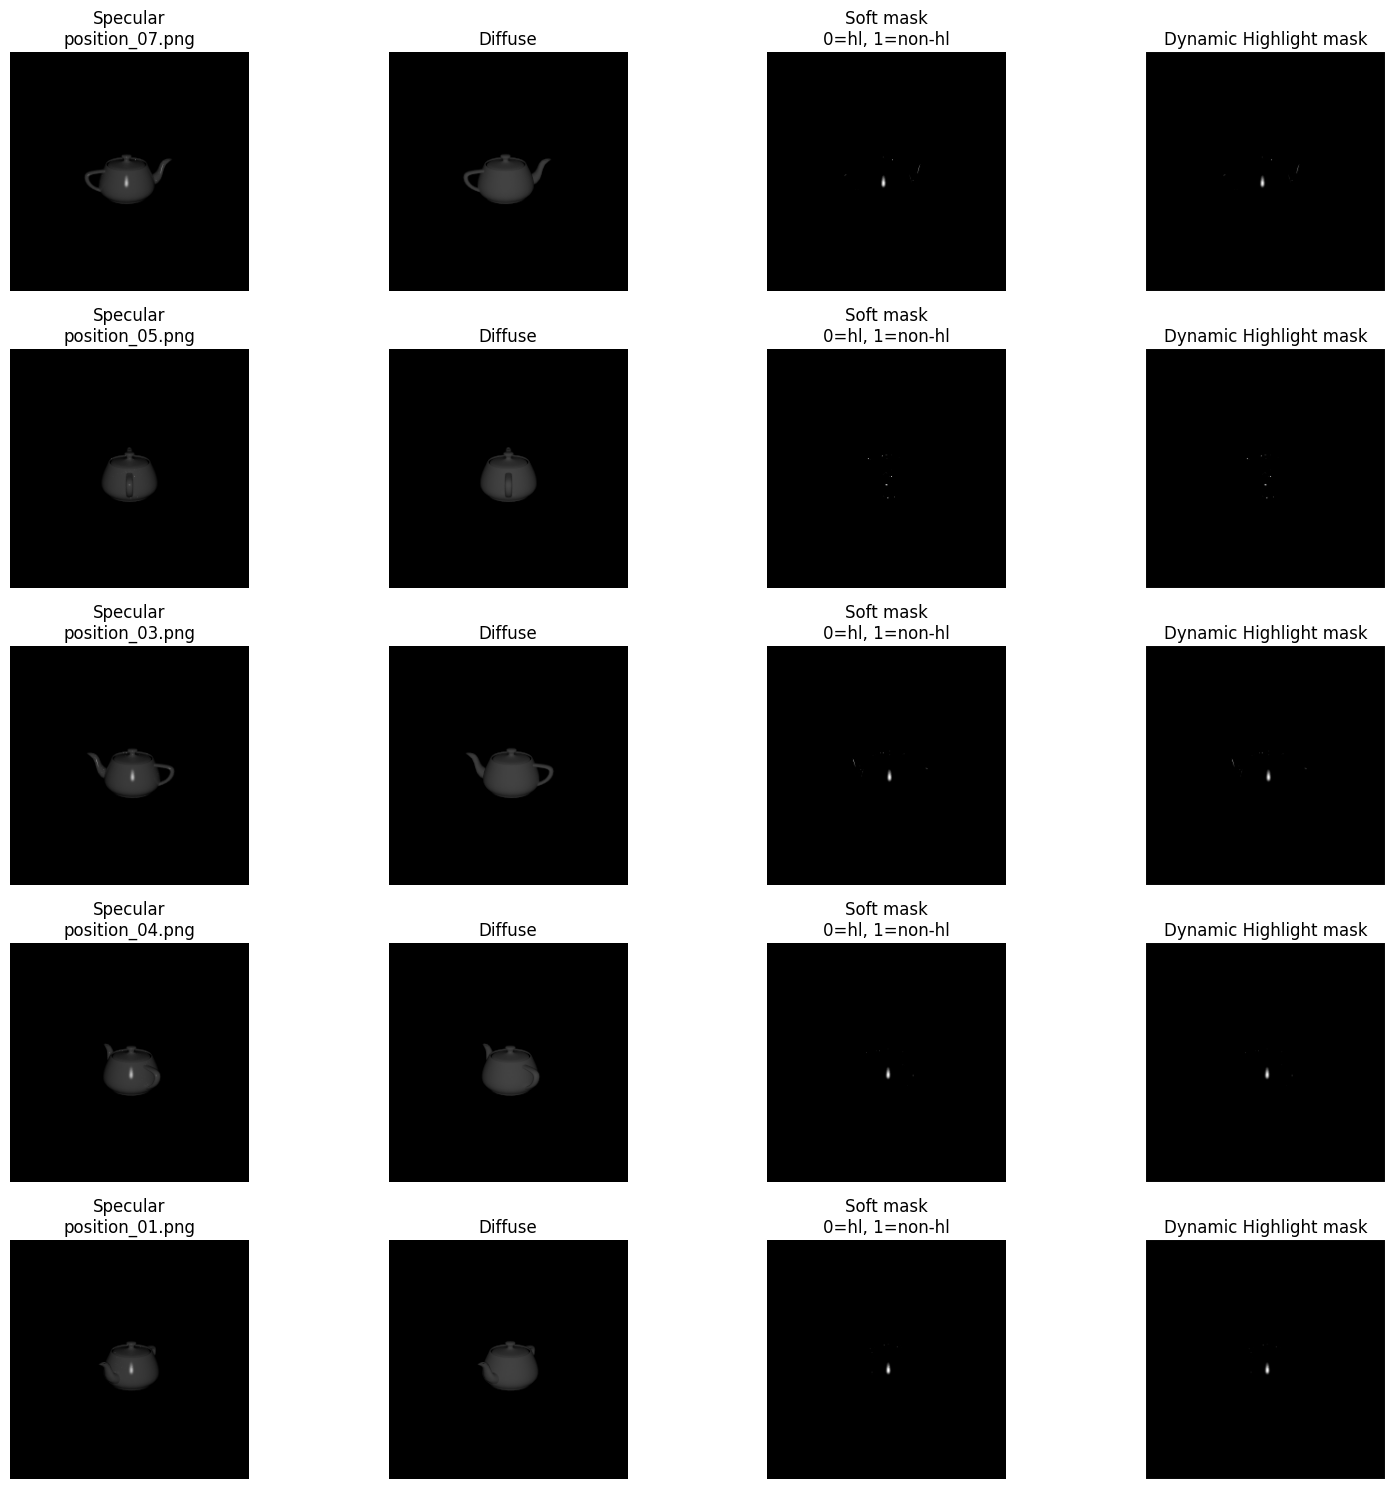

In [55]:
teapot_dataset, teapot_loader = load_rendered_object_dataset("teapot")
show_5_random_samples(teapot_dataset, show_thresholded=True)


In [56]:
ply_path, mesh = scene_builder.stl_to_ply(
    str(PROJECT_ROOT / "data" / "objects" / "turbine" / "Turbine.STL"),
    None,
    smooth_iterations=10,
    lambda_factor=0.2,
)
print(ply_path)


/Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/turbine/Turbine.ply


In [57]:
turbine = ply_path
template_xml = str(PROJECT_ROOT / "data" / "scene.xml")
turbinegenerated_dir = str(PROJECT_ROOT / "data" / "objects" / "turbine" / "scenes")

turbine_diffuse_scene_path, turbine_scene_info = scene_builder.buildscene(
    objectpath=turbine,
    material_mode="diffuse",
    template_xml_path=template_xml,
    output_dir=turbinegenerated_dir,
)

turbine_glossy_scene_path, _ = scene_builder.buildscene(
    objectpath=turbine,
    material_mode="glossy",
    template_xml_path=template_xml,
    output_dir=turbinegenerated_dir,
)

print("Diffuse scene:", turbine_diffuse_scene_path)
print("Glossy scene :", turbine_glossy_scene_path)
print("Scene info:")
turbine_scene_info


Diffuse scene: /Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/turbine/scenes/Turbine_diffuse.xml
Glossy scene : /Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/turbine/scenes/Turbine_glossy.xml
Scene info:


{'objectpath': '/Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/turbine/Turbine.ply',
 'saved_scene_path': '/Users/27171653/Desktop/PhD/Specular-Highlights/data/objects/turbine/scenes/Turbine_diffuse.xml',
 'material_mode': 'diffuse',
 'mesh_bounds_min': [105.79936981201172, 88.31564331054688, 104.4749526977539],
 'mesh_bounds_max': [228.67291259765625,
  114.96955871582031,
  228.52716064453125],
 'centre': [167.23614120483398, 101.6426010131836, 166.50105667114258],
 'extent': [122.87354278564453, 26.653915405273438, 124.05220794677734],
 'size': 124.05220794677734,
 'n_views': 10,
 'n_lights': 8,
 'ring_tilt_deg': 0.0,
 'up': [0.0, 0.0, 1.0],
 'target': [167.23614120483398, 101.6426010131836, 178.90627746582032],
 'orbit_radius': 496.2088317871094,
 'orbit_height': 352.5793685913086,
 'ring_radius': 18.6078311920166,
 'ring_forward': 9.924176635742187,
 'cam_target_distance': 525.7238318020308,
 'light_target_distance': 516.1351912545131,
 'spp': 256,
 'res': 256,
 'rin

In [58]:
m3_gen.render_dataset_from_sceneinfo(
    model="turbine",
    diffuse_scene_path=turbine_diffuse_scene_path,
    glossy_scene_path=turbine_glossy_scene_path,
    scene_info=turbine_scene_info,
)

2026-03-16 19:29:32 WARN  [ply.h:367] "Turbine.ply": attributes without postfix are not handled for now: attribute "stl" ignored.
2026-03-16 19:29:32 WARN  [ply.h:367] "Turbine.ply": attributes without postfix are not handled for now: attribute "stl" ignored.
Rendered position_00 | diffuse + glossy
Rendered position_01 | diffuse + glossy
Rendered position_02 | diffuse + glossy
Rendered position_03 | diffuse + glossy
Rendered position_04 | diffuse + glossy
Rendered position_05 | diffuse + glossy
Rendered position_06 | diffuse + glossy
Rendered position_07 | diffuse + glossy
Rendered position_08 | diffuse + glossy
Rendered position_09 | diffuse + glossy
Done. Rendered 10 paired positions.


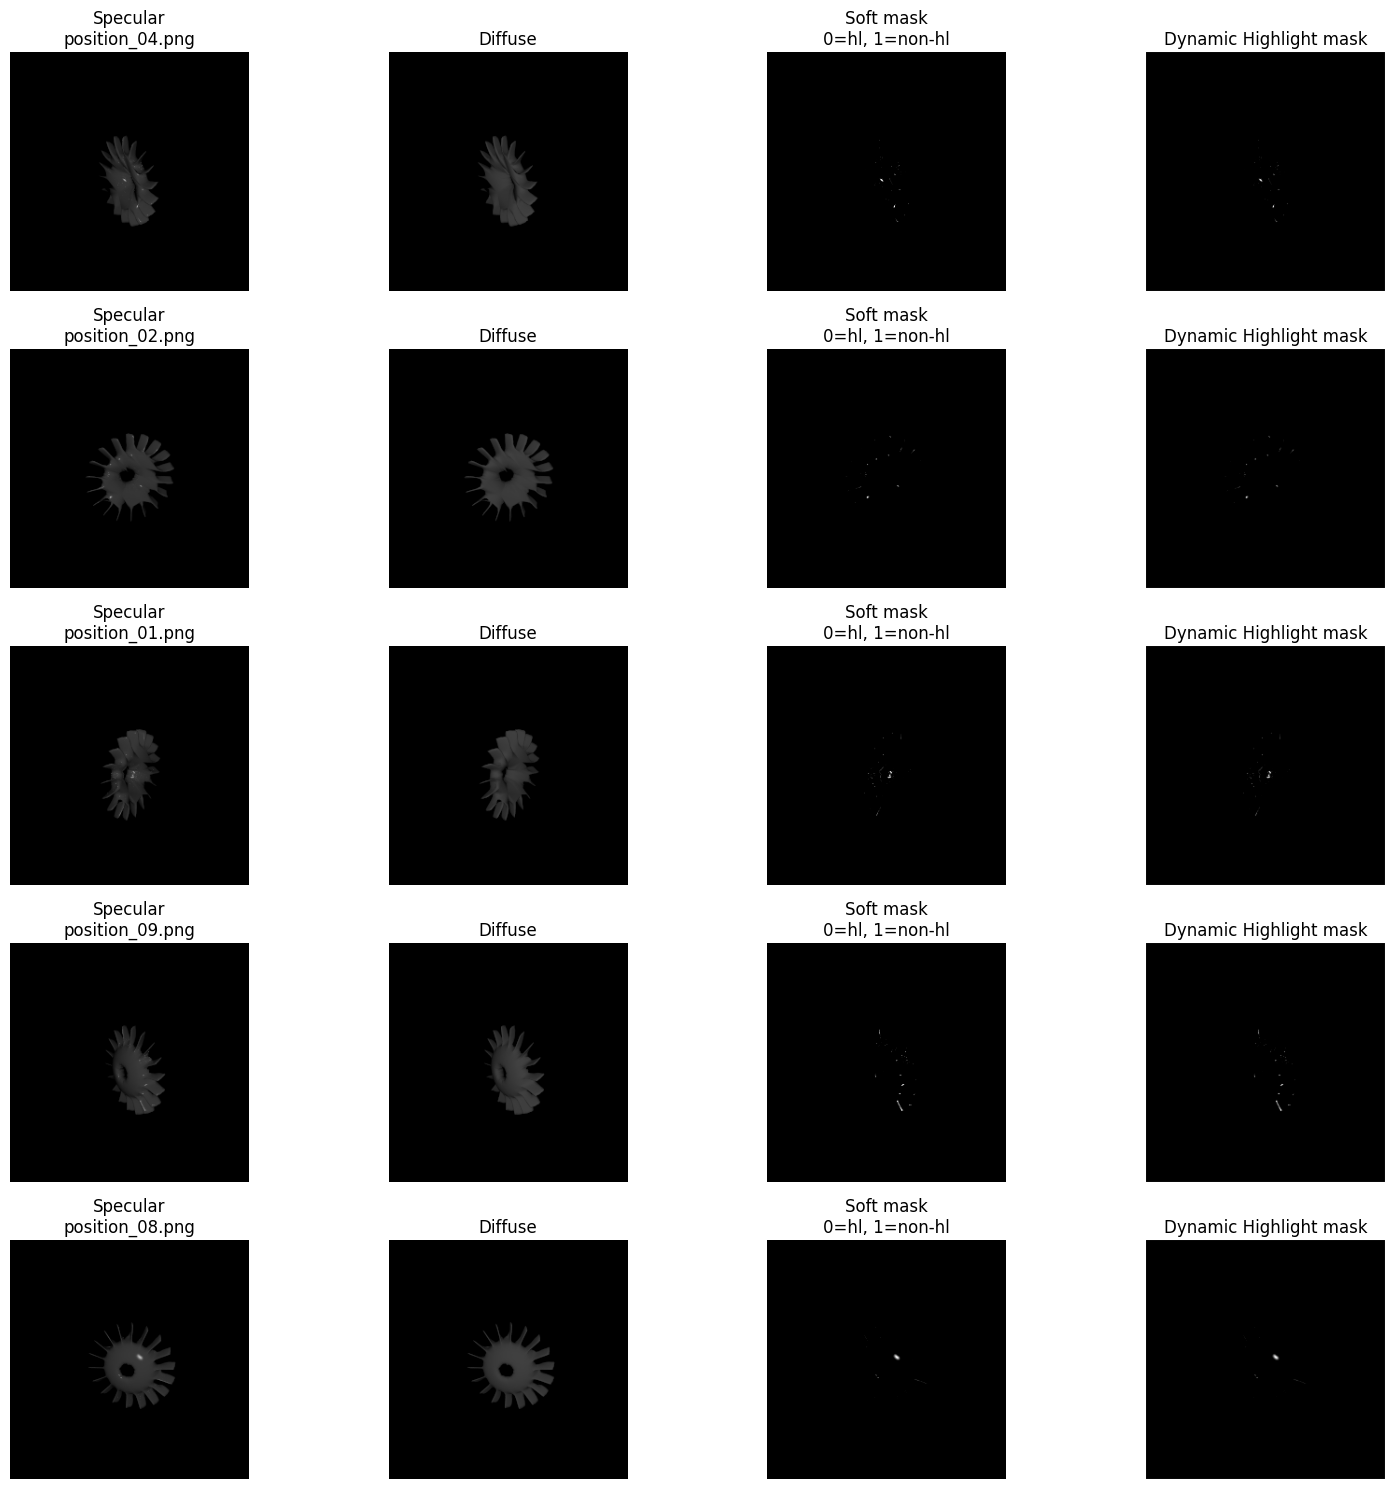

In [59]:
turbine_dataset, turbine_loader = load_rendered_object_dataset("turbine")
show_5_random_samples(turbine_dataset, show_thresholded=True)


=== teapot (10 samples) ===


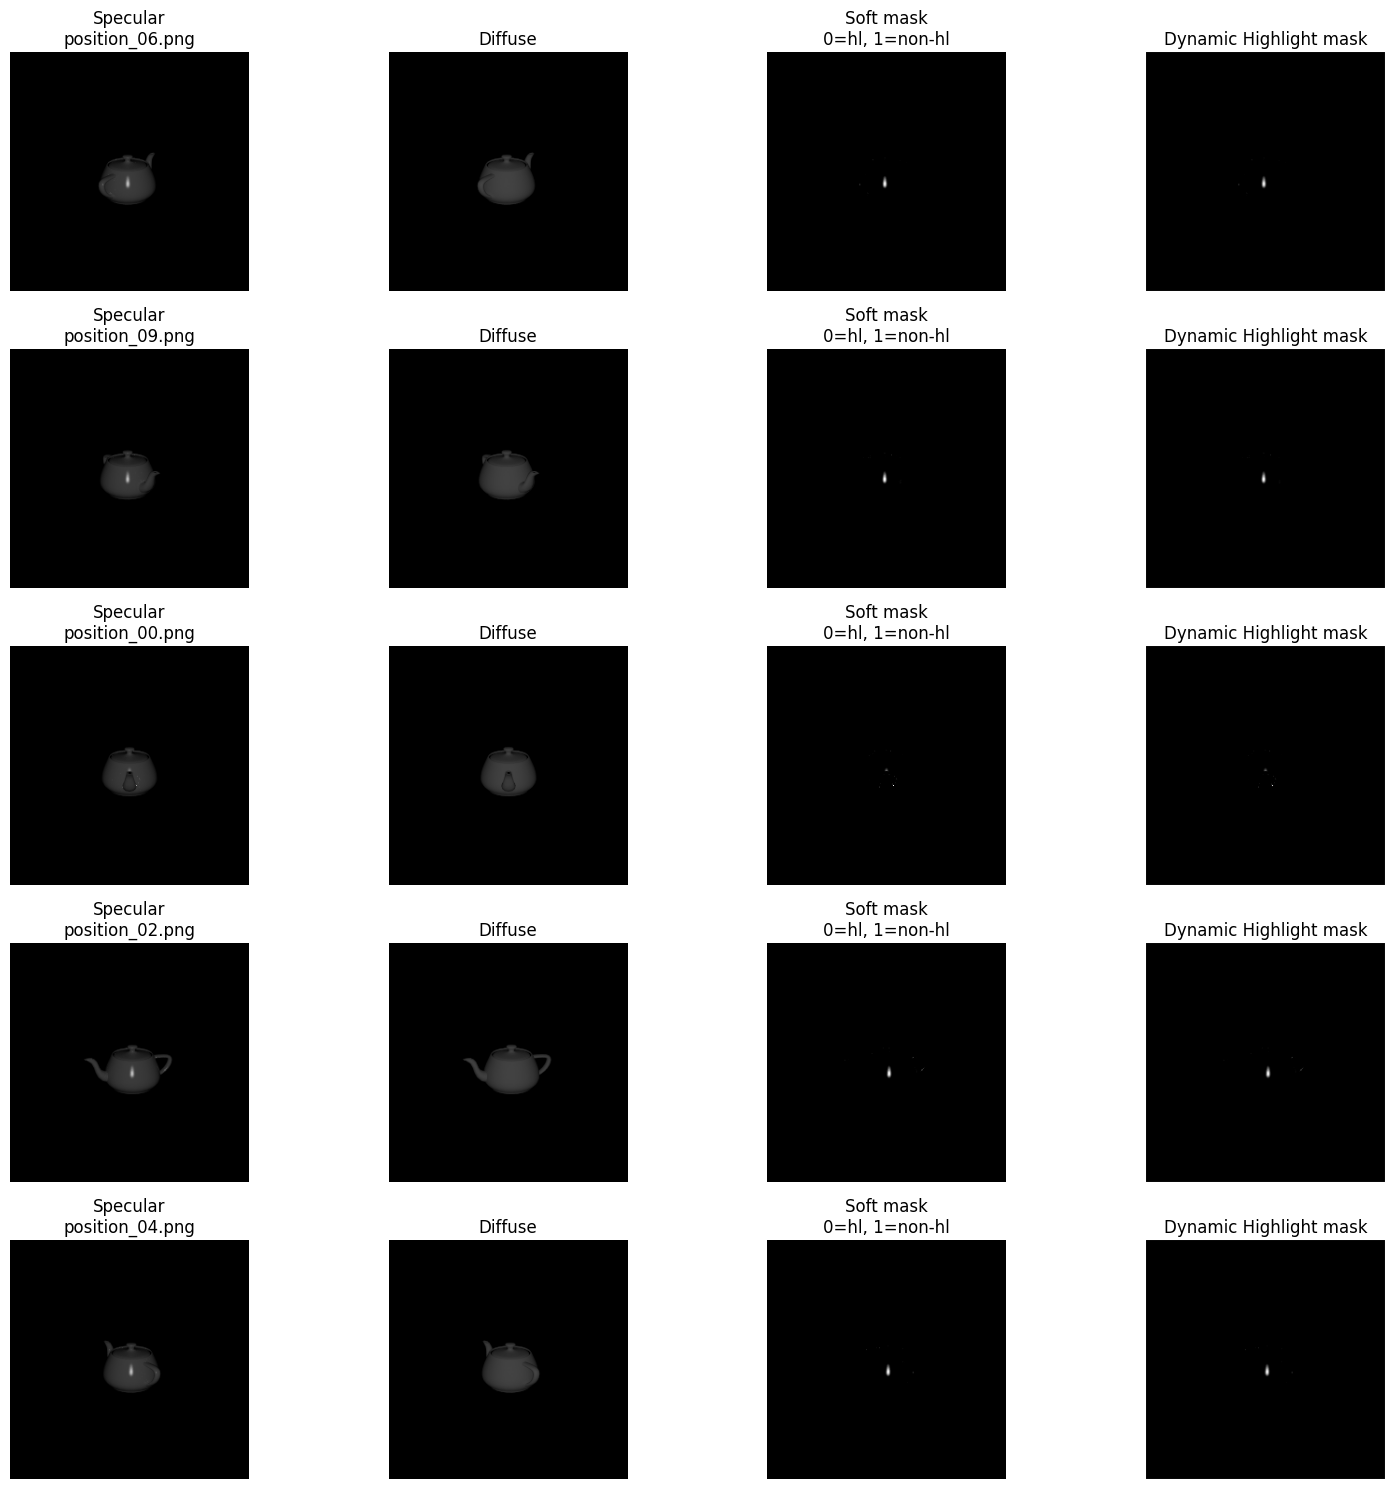

=== turbine (10 samples) ===


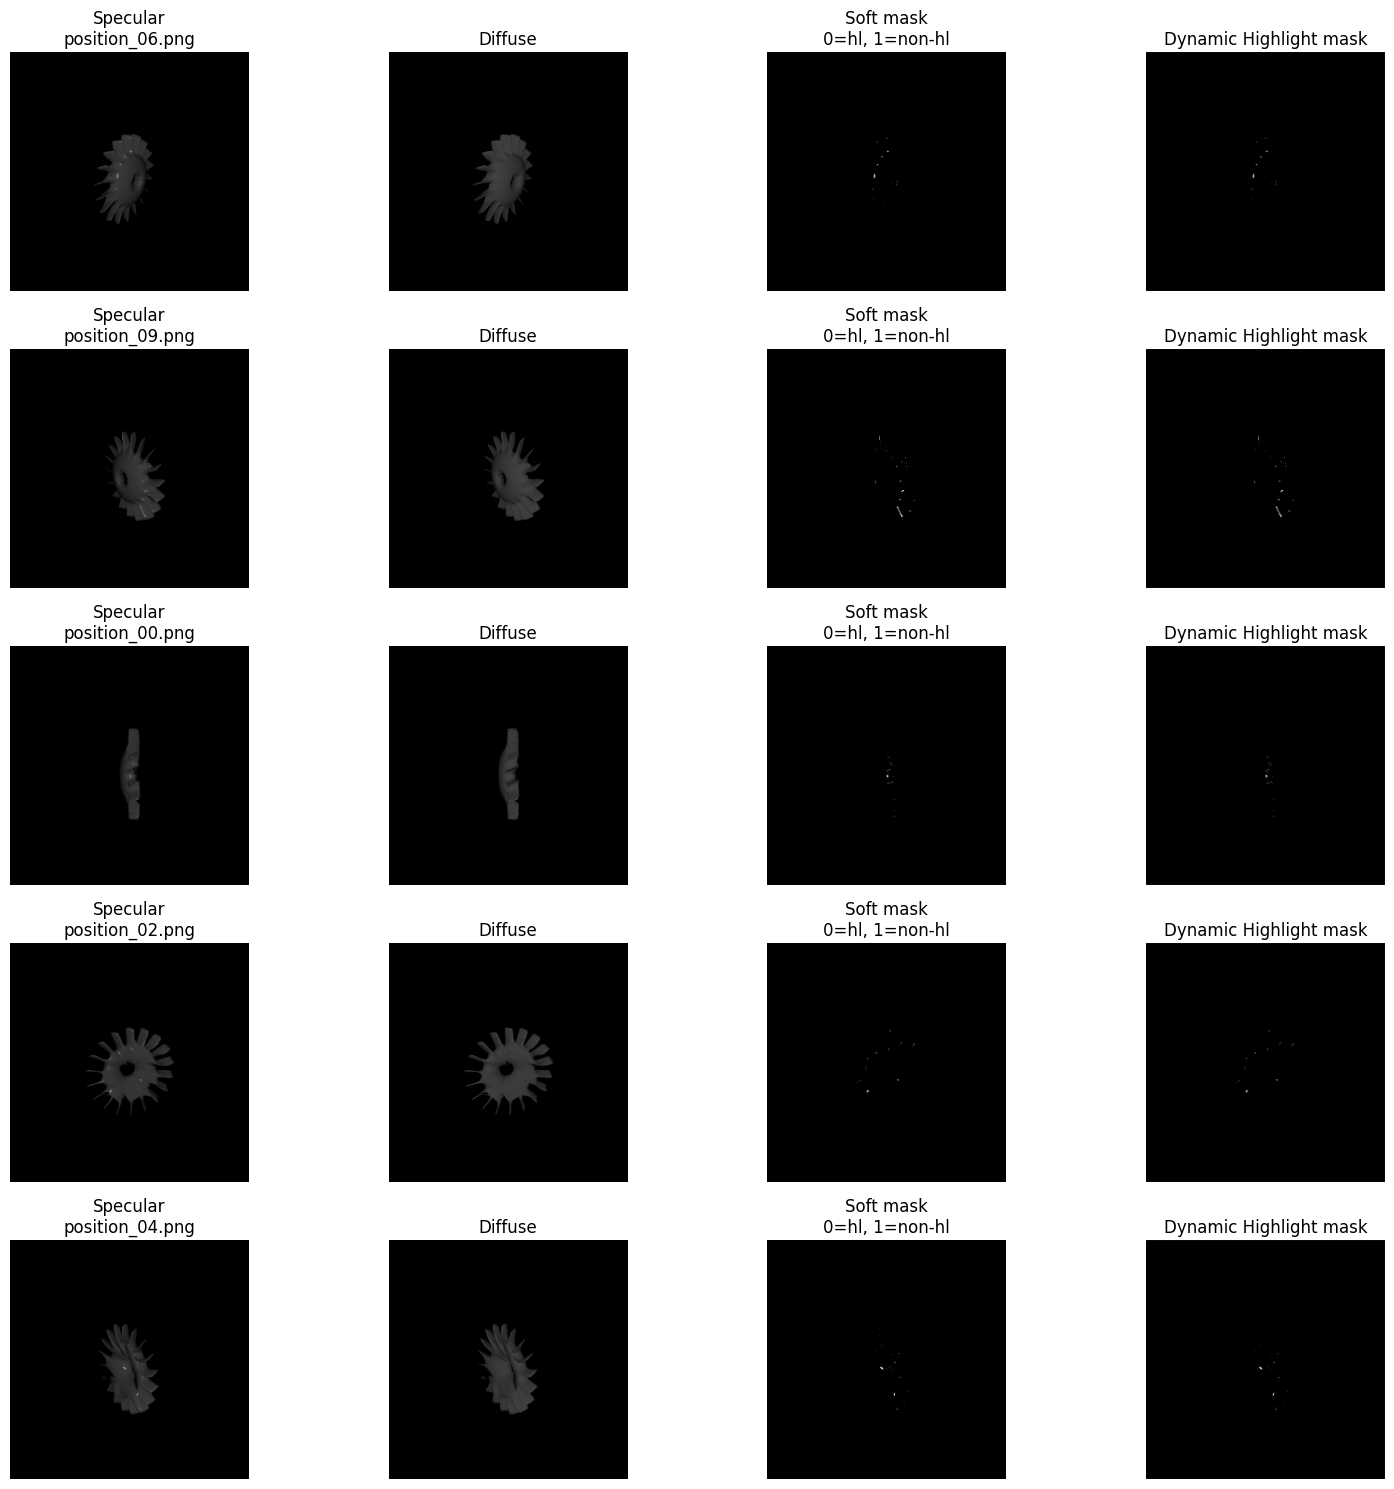

=== can (10 samples) ===


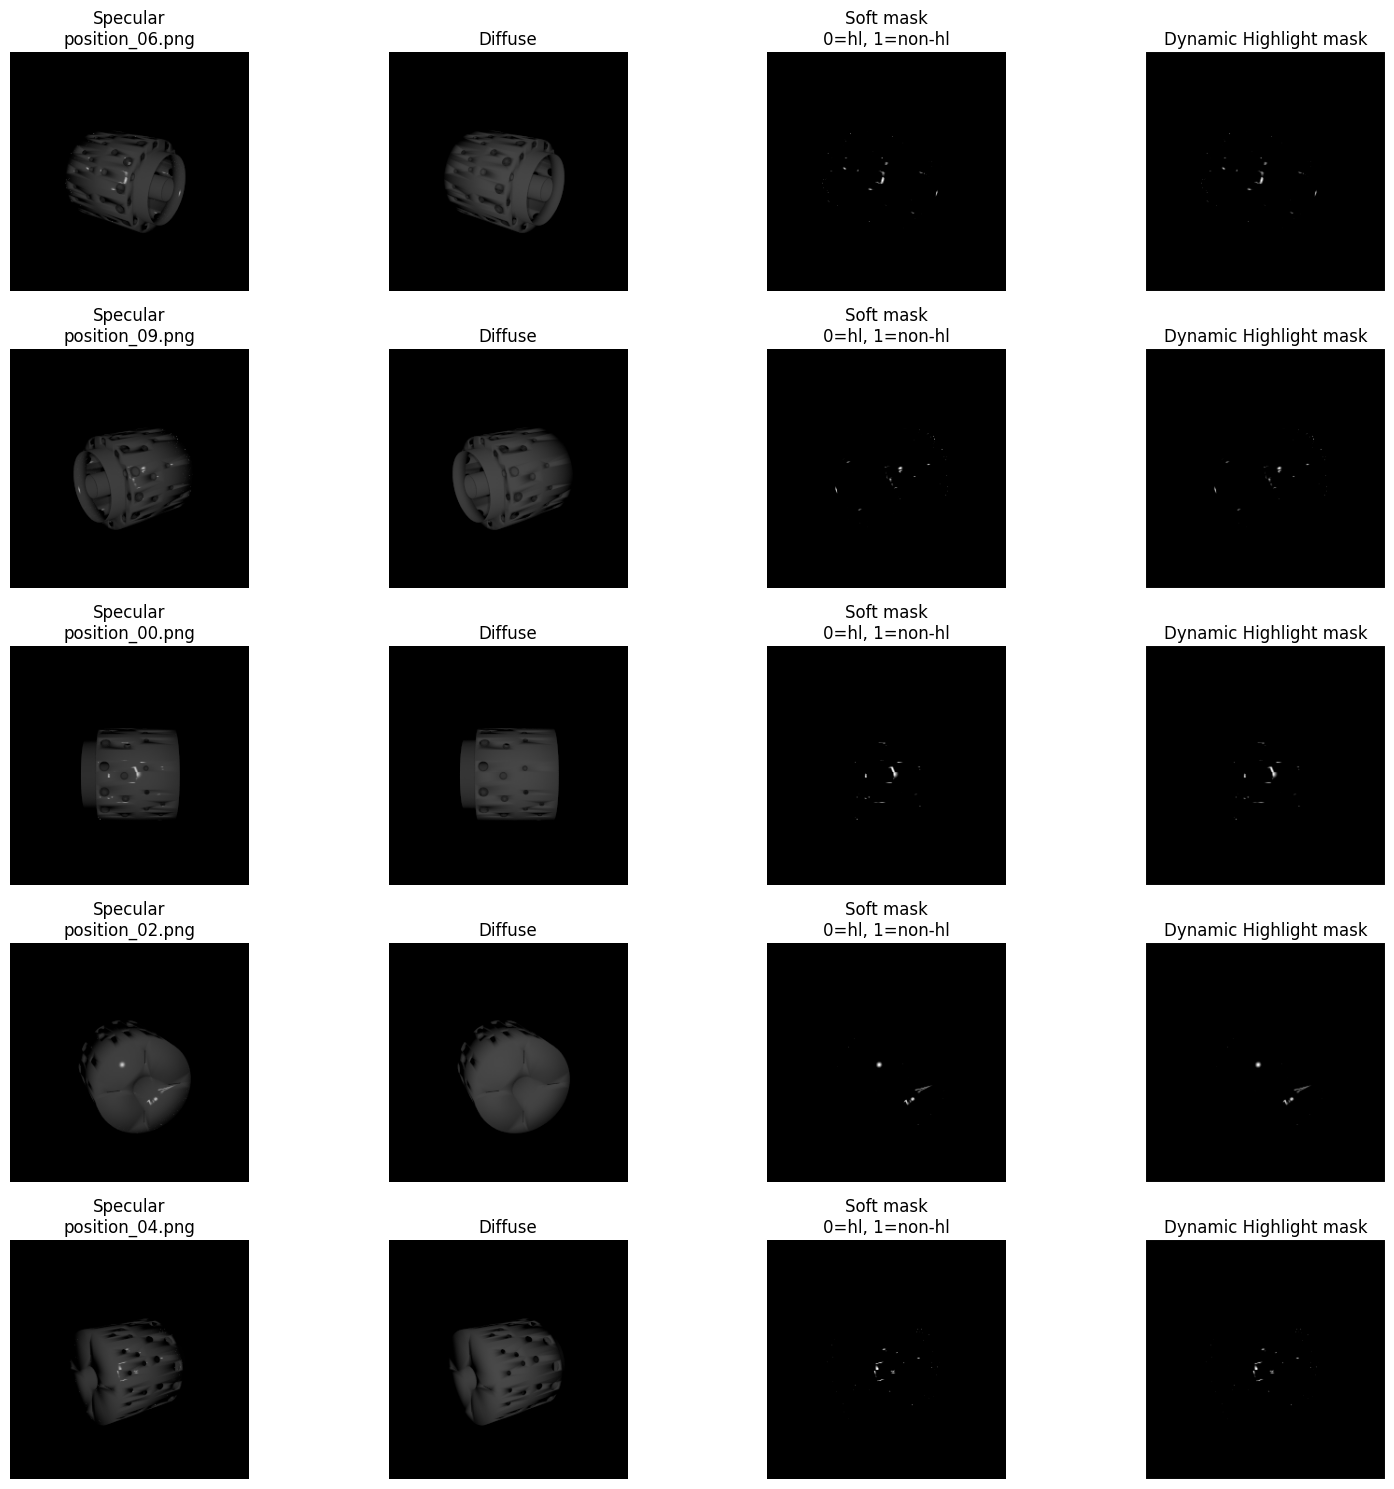

=== case (10 samples) ===


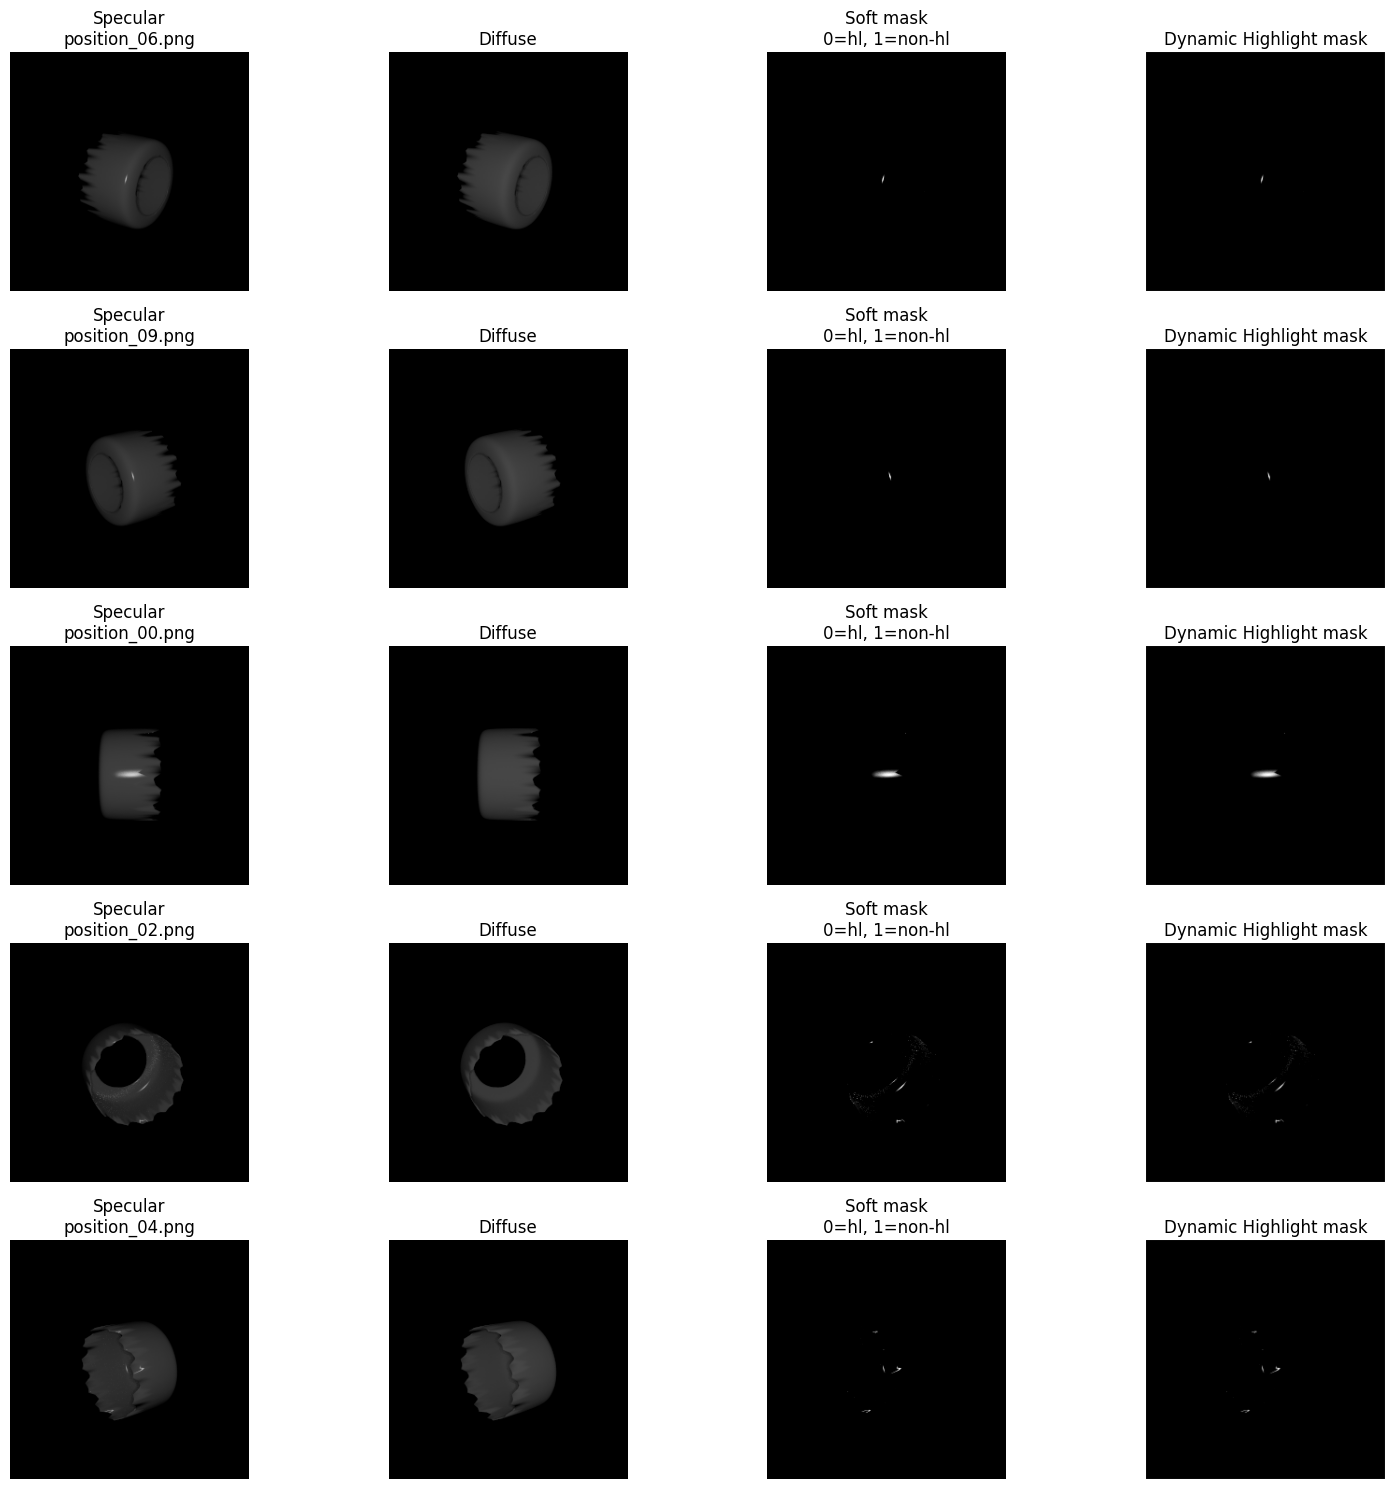

=== guide_vane (10 samples) ===


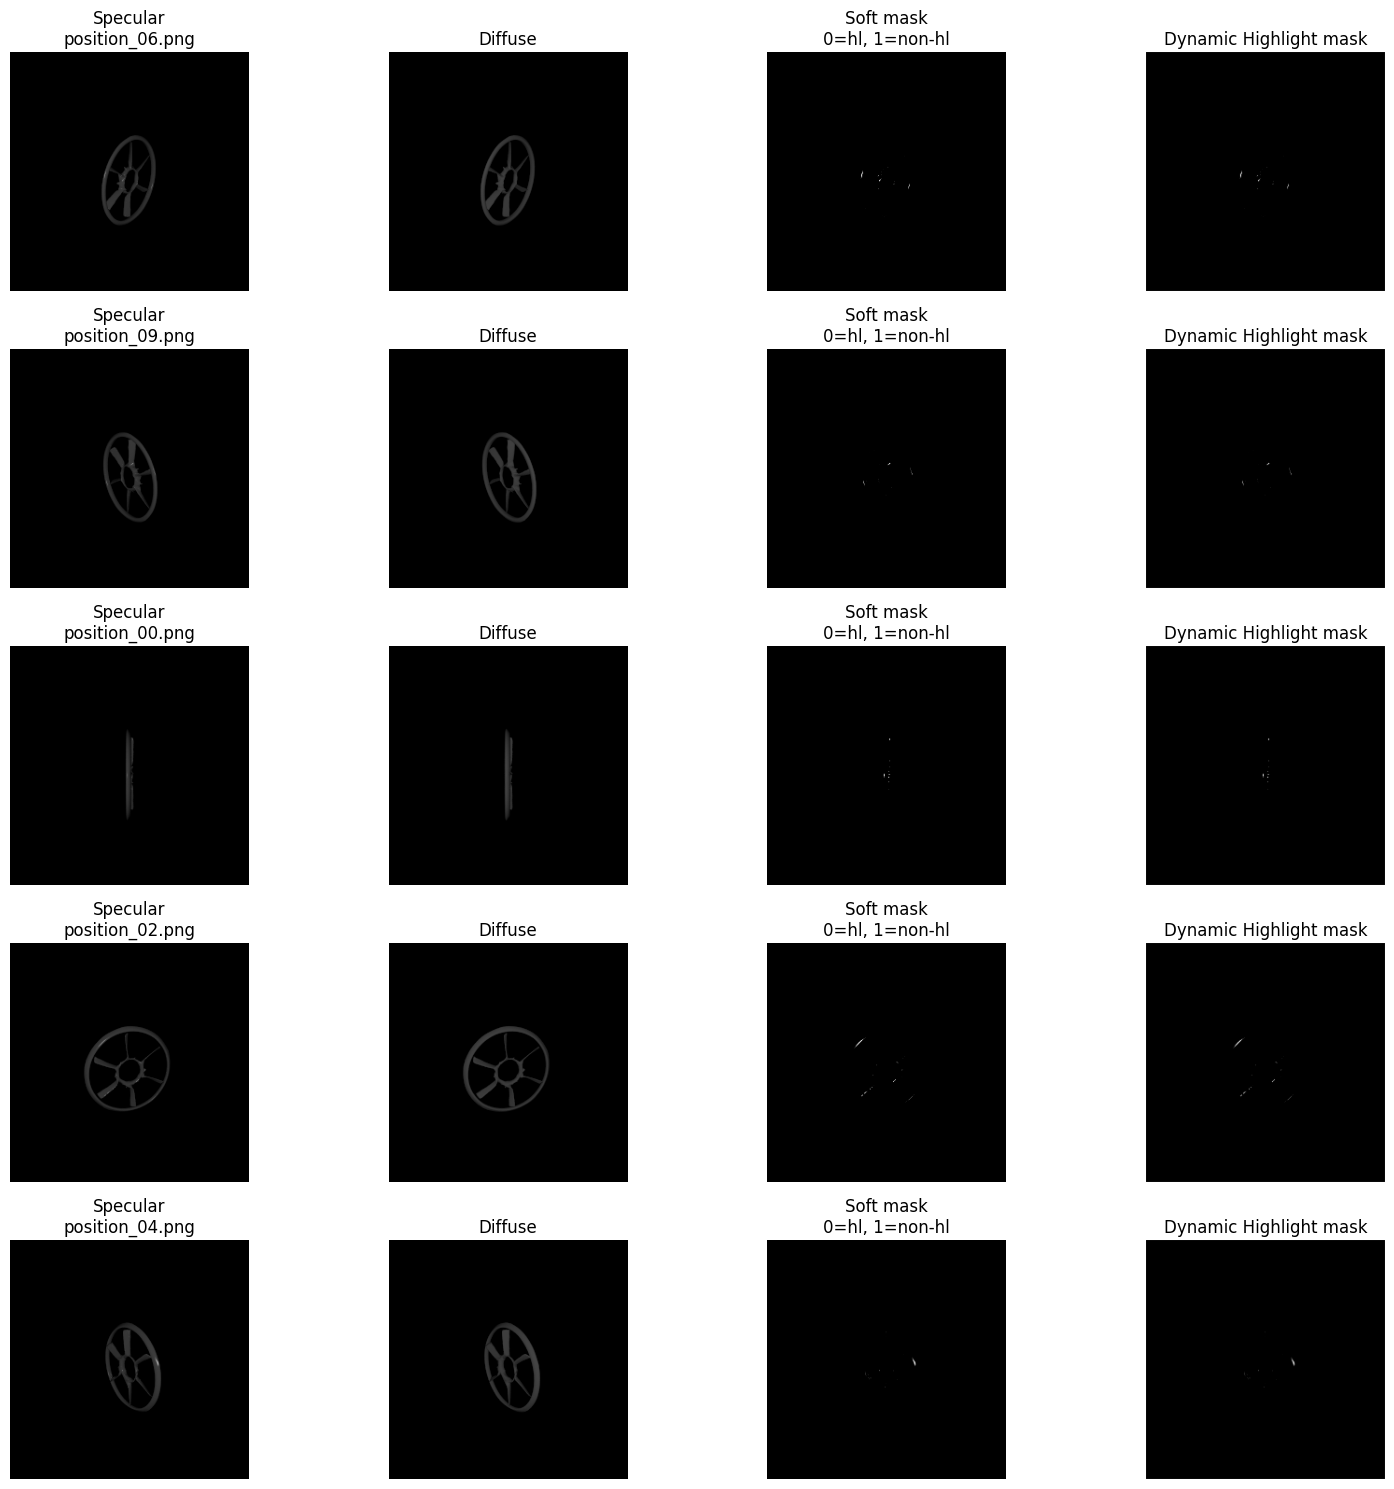

In [60]:
all_object_datasets = {}

for model_name in RENDERED_OBJECTS:
    dataset, loader = visualize_rendered_object(
        model_name,
        seed=0,
        show_thresholded=True,
    )
    all_object_datasets[model_name] = dataset


In [61]:
import random
import importlib
import matplotlib.pyplot as plt
import torch
from pipeline import ResidualLoader as residual_loader
residual_loader = importlib.reload(residual_loader)

def load_rendered_object_residual_dataset(
    model_name,
    batch_size=4,
    threshold=0.9,
    soft_gamma=1.0,
    residual_mode="additive",
    threshold_method="otsu",
):
    diffuse_dir = PROJECT_ROOT / "data" / "train" / model_name / "diffuse"
    glossy_dir = PROJECT_ROOT / "data" / "train" / model_name / "glossy"

    dataset, loader = residual_loader.make_residual_dataloader(
        diffuse_dir=str(diffuse_dir),
        glossy_dir=str(glossy_dir),
        batch_size=batch_size,
        soft_gamma=soft_gamma,
        threshold_method=threshold_method,
        threshold=threshold,
        residual_mode=residual_mode,
    )

    return dataset, loader


def _residual_to_vis(residual_tensor):
    residual_vis = residual_tensor.detach().cpu().permute(1, 2, 0)
    residual_vis = residual_vis - residual_vis.min()
    residual_vis = residual_vis / (residual_vis.max() + 1e-8)
    return residual_vis.clamp(0.0, 1.0)


def show_residual_samples(dataset, indices=None, n_random=None, seed=None, residual_mode="additive"):
    if len(dataset) == 0:
        raise ValueError("Dataset is empty.")

    if indices is None and n_random is None:
        indices = [1]

    if seed is not None:
        random.seed(seed)

    if indices is not None:
        if isinstance(indices, int):
            indices = [indices]
        zero_based_indices = [idx - 1 for idx in indices]
    else:
        n_random = min(n_random, len(dataset))
        zero_based_indices = random.sample(range(len(dataset)), n_random)

    n = len(zero_based_indices)
    fig, axes = plt.subplots(n, 8, figsize=(30, 4 * n))

    if n == 1:
        axes = [axes]

    for row, ds_idx in enumerate(zero_based_indices):
        sample = dataset[ds_idx]

        glossy = sample["input"].detach().cpu().permute(1, 2, 0)
        diffuse = sample["diffuse"].detach().cpu().permute(1, 2, 0)
        unmasked_residual = sample["unmasked_residual"]
        masked_residual = sample["masked_residual"]
        reconstructed_full = residual_loader.reconstruct_diffuse(
            sample["input"],
            unmasked_residual,
            residual_mode=residual_mode,
        ).detach().cpu().permute(1, 2, 0)
        reconstructed_masked = residual_loader.reconstruct_diffuse(
            sample["input"],
            masked_residual,
            residual_mode=residual_mode,
        ).detach().cpu().permute(1, 2, 0)

        unmasked_residual_vis = _residual_to_vis(unmasked_residual)
        masked_residual_vis = _residual_to_vis(masked_residual)

        soft_mask = sample["soft_mask"].detach().cpu()[0]
        residual_mask = sample["mask"].detach().cpu()[0]
        name_text = sample.get("name", f"item {ds_idx + 1}")

        ax = axes[row]

        ax[0].imshow(glossy)
        ax[0].set_title(f"Glossy\n{name_text}")
        ax[0].axis("off")

        ax[1].imshow(diffuse)
        ax[1].set_title("Diffuse")
        ax[1].axis("off")

        ax[2].imshow(unmasked_residual_vis)
        ax[2].set_title(f"{residual_mode} residual\n(full)")
        ax[2].axis("off")

        ax[3].imshow(masked_residual_vis)
        ax[3].set_title(f"{residual_mode} residual\n(Otsu masked)")
        ax[3].axis("off")

        ax[4].imshow(reconstructed_full.clamp(0.0, 1.0))
        ax[4].set_title("Reconstructed diffuse\nfrom full residual")
        ax[4].axis("off")

        ax[5].imshow(reconstructed_masked.clamp(0.0, 1.0))
        ax[5].set_title("Reconstructed diffuse\nfrom masked residual")
        ax[5].axis("off")

        ax[6].imshow(soft_mask, cmap="gray", vmin=0, vmax=1)
        ax[6].set_title("Residual strength map")
        ax[6].axis("off")

        ax[7].imshow(residual_mask, cmap="gray", vmin=0, vmax=1)
        ax[7].set_title("Otsu residual mask")
        ax[7].axis("off")

    plt.tight_layout()
    plt.show()


def residual_reconstruction_error(dataset, residual_mode="additive", n_samples=5):
    unmasked_recon_max_err = 0.0
    masked_recon_full_max_err = 0.0
    masked_recon_inside_mask_max_err = 0.0

    for idx in range(min(n_samples, len(dataset))):
        sample = dataset[idx]
        reconstructed_unmasked = residual_loader.reconstruct_diffuse(
            sample["input"],
            sample["unmasked_residual"],
            residual_mode=residual_mode,
        )
        reconstructed_masked = residual_loader.reconstruct_diffuse(
            sample["input"],
            sample["masked_residual"],
            residual_mode=residual_mode,
        )
        unmasked_err = (reconstructed_unmasked - sample["diffuse"]).abs()
        masked_err = (reconstructed_masked - sample["diffuse"]).abs()
        residual_mask = sample["mask"].expand_as(sample["masked_residual"])
        unmasked_recon_max_err = max(unmasked_recon_max_err, unmasked_err.max().item())
        masked_recon_full_max_err = max(masked_recon_full_max_err, masked_err.max().item())
        masked_recon_inside_mask_max_err = max(
            masked_recon_inside_mask_max_err,
            (masked_err * residual_mask).max().item(),
        )

    return {
        "unmasked_recon_max_err": unmasked_recon_max_err,
        "masked_recon_full_max_err": masked_recon_full_max_err,
        "masked_recon_inside_mask_max_err": masked_recon_inside_mask_max_err,
    }


=== can additive residual dataset (10 samples) ===
formula: diffuse = glossy + residual
showing both full residuals and Otsu-masked residuals


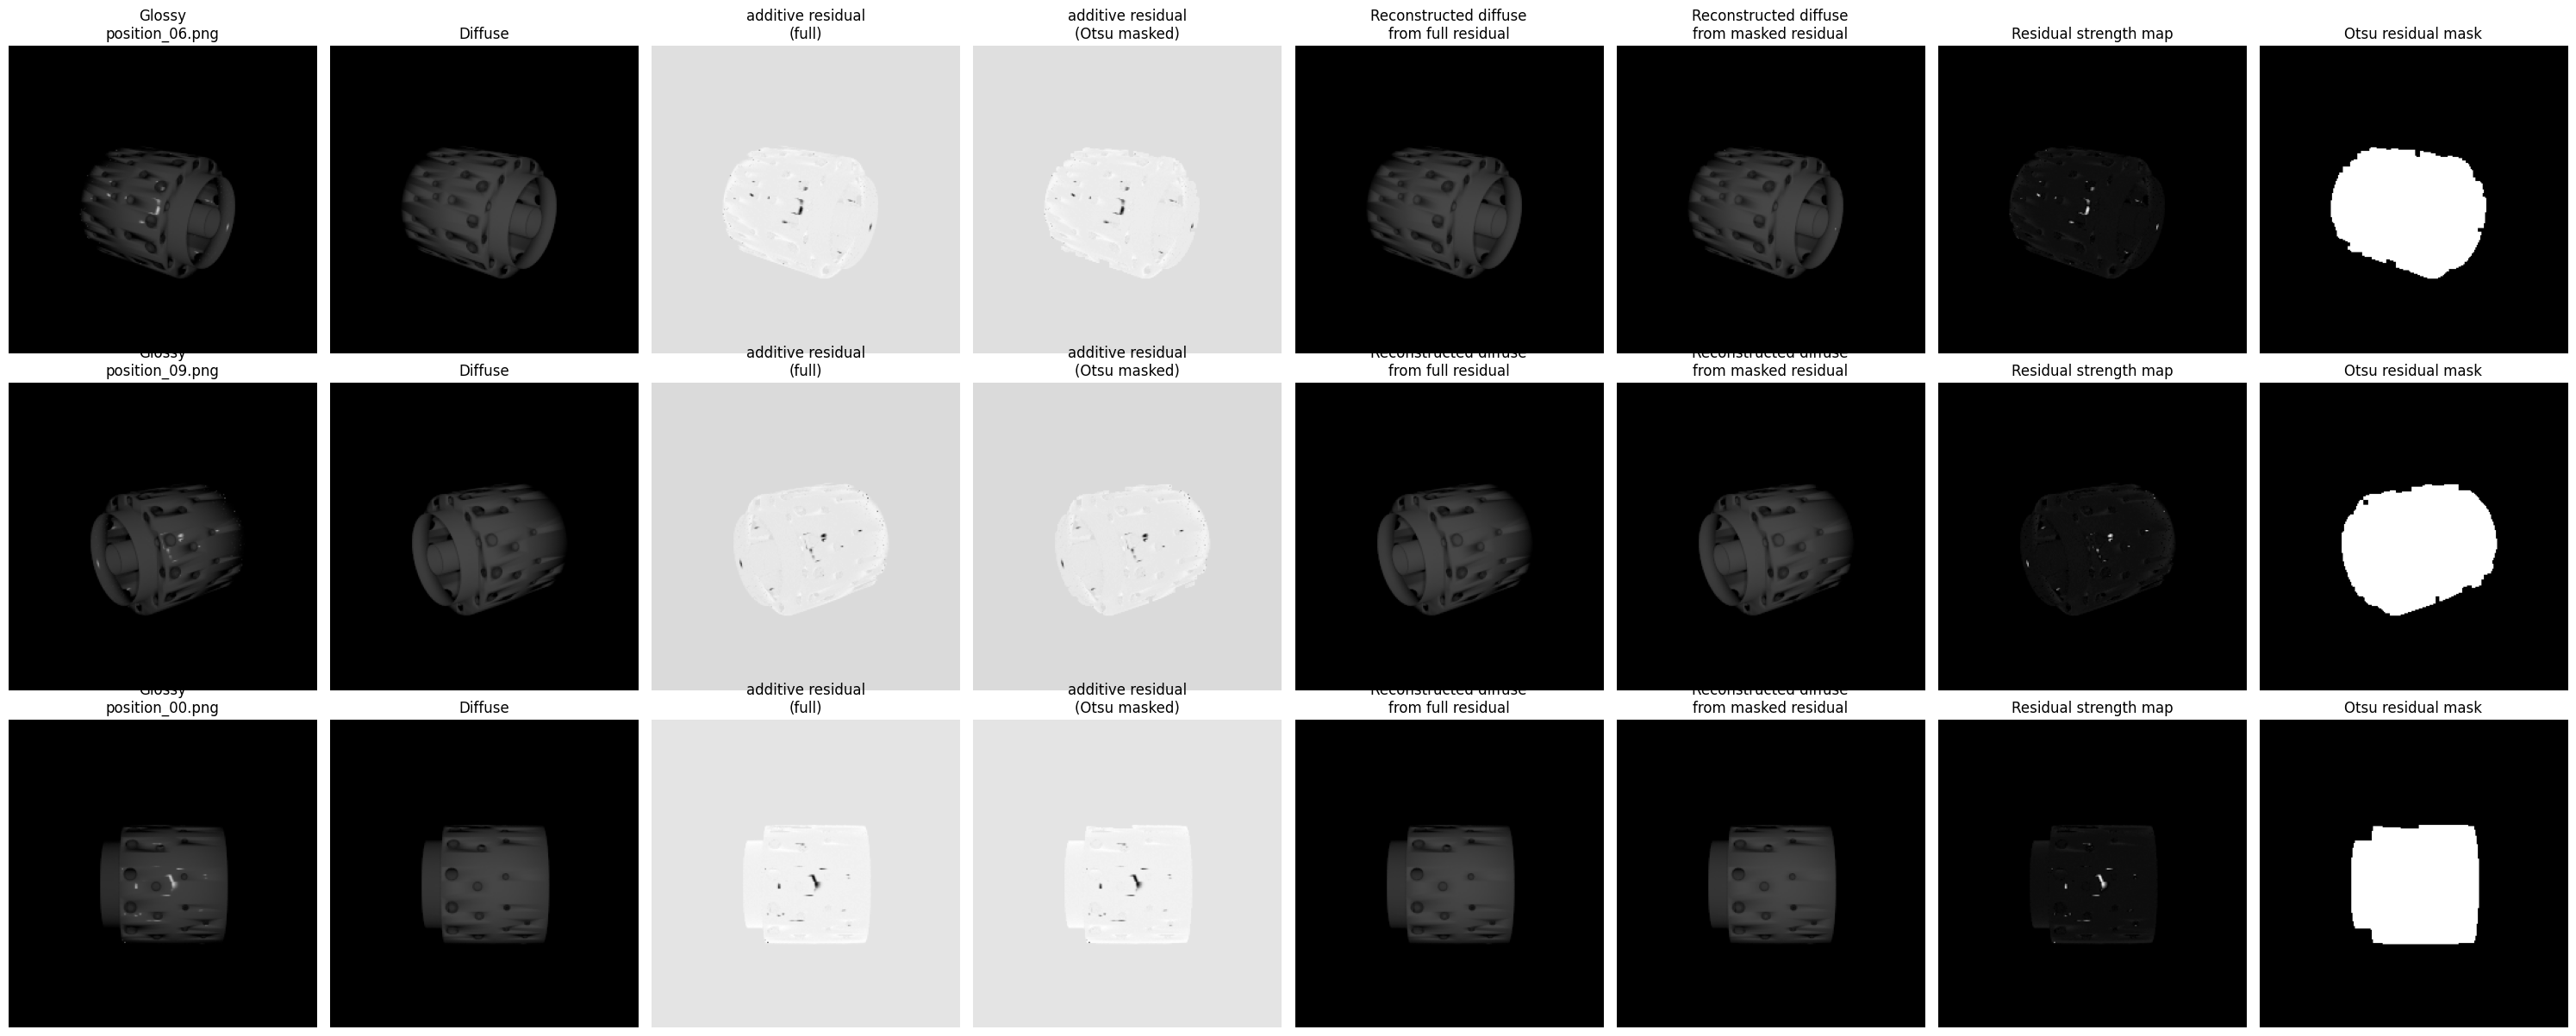

In [62]:
residual_model_name = "can"

additive_residual_dataset, additive_residual_loader = load_rendered_object_residual_dataset(
    residual_model_name,
    batch_size=4,
    threshold=0.9,
    soft_gamma=1.0,
    residual_mode="additive",
    threshold_method="otsu",
)

print(f"=== {residual_model_name} additive residual dataset ({len(additive_residual_dataset)} samples) ===")
print("formula: diffuse = glossy + residual")
print("showing both full residuals and Otsu-masked residuals")
show_residual_samples(
    additive_residual_dataset,
    n_random=3,
    seed=0,
    residual_mode="additive",
)


=== can subtractive residual dataset (10 samples) ===
formula: diffuse = glossy - residual
showing both full residuals and Otsu-masked residuals


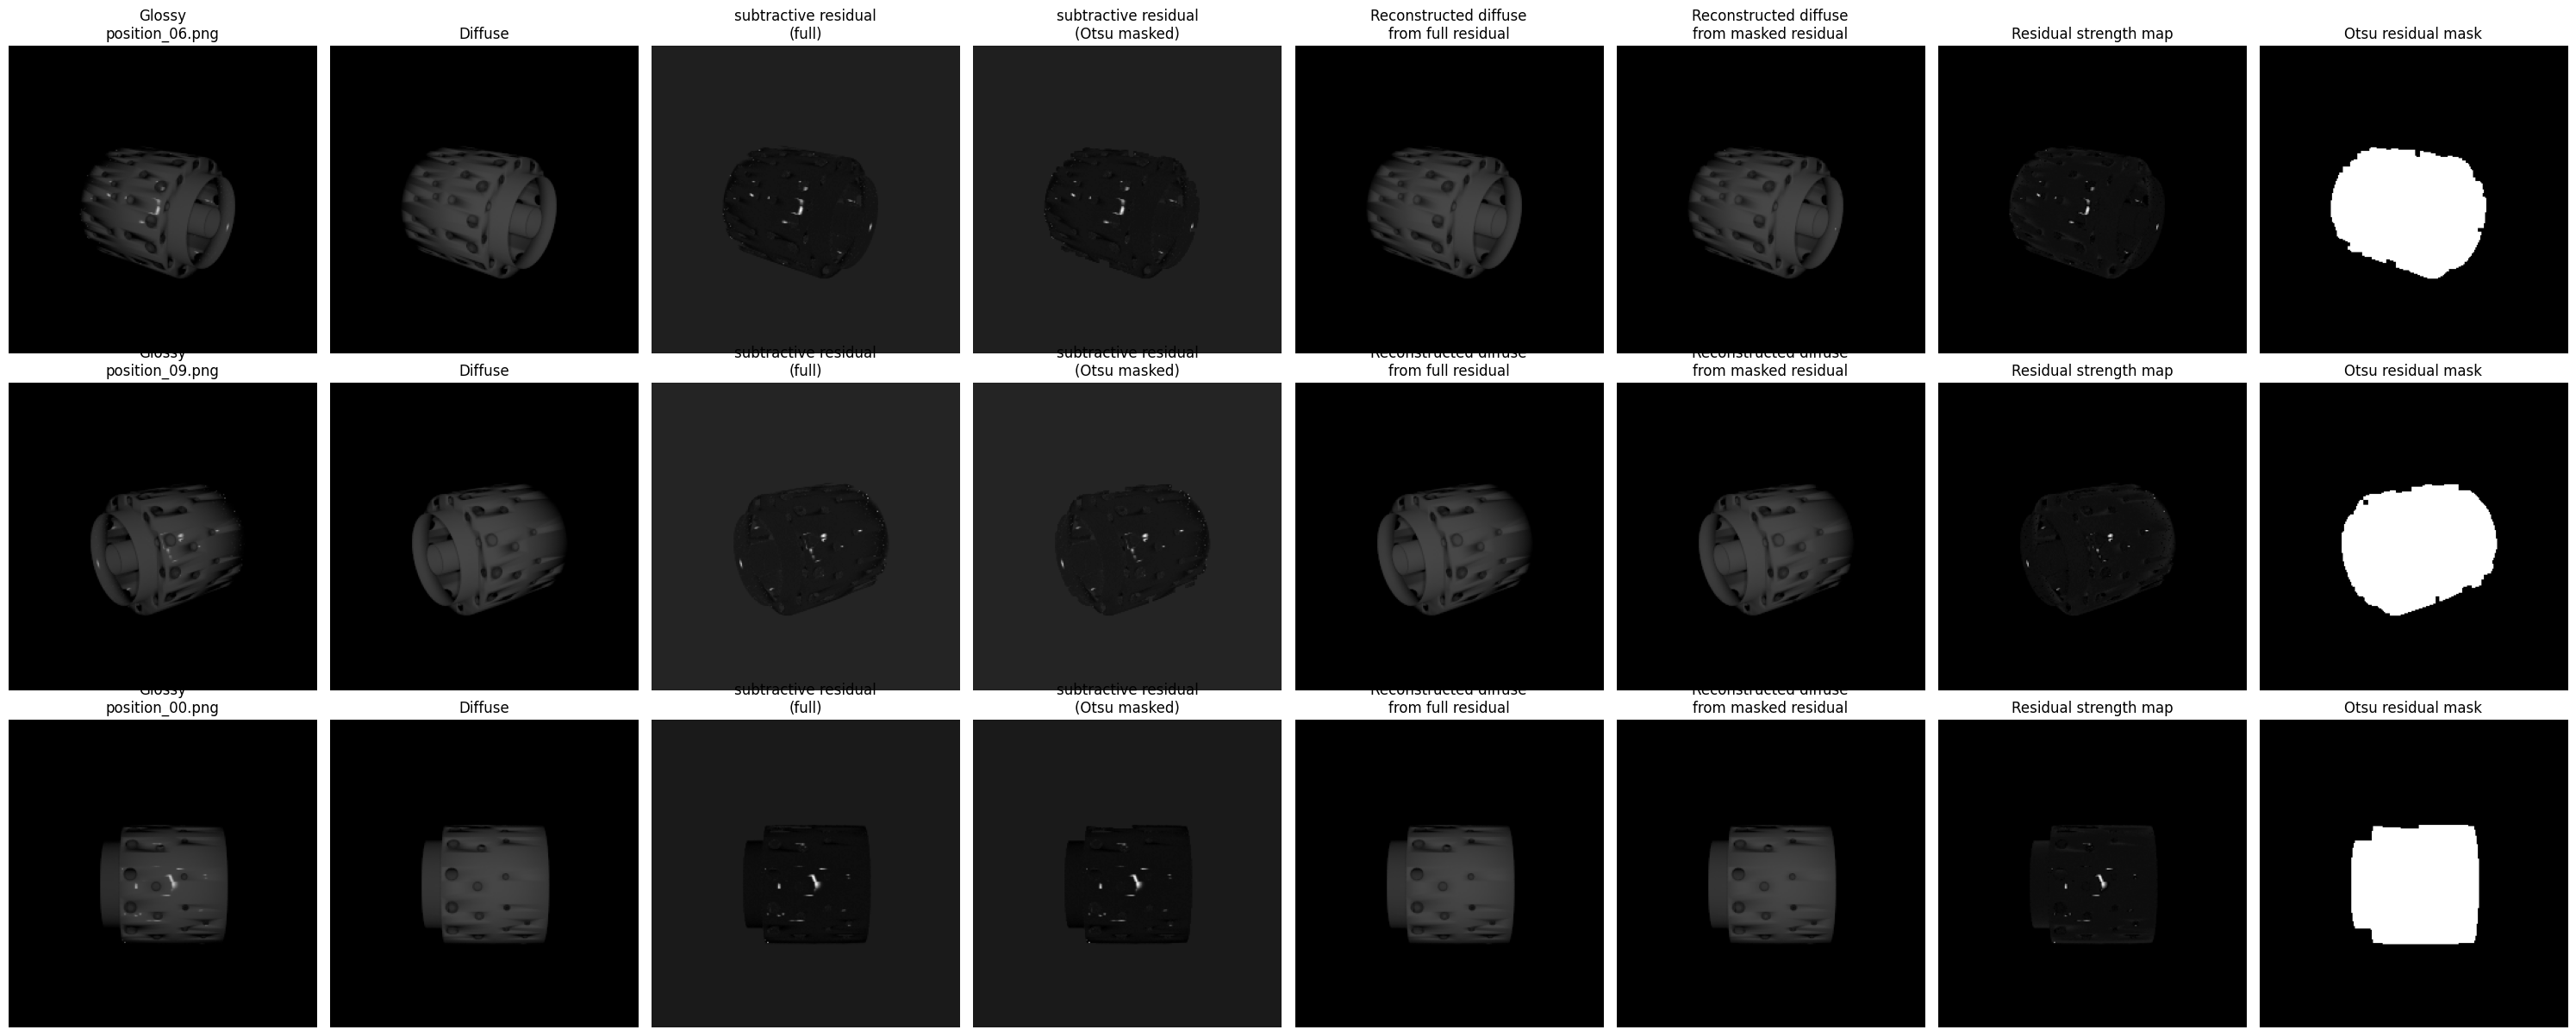

In [63]:
subtractive_residual_dataset, subtractive_residual_loader = load_rendered_object_residual_dataset(
    residual_model_name,
    batch_size=4,
    threshold=0.9,
    soft_gamma=1.0,
    residual_mode="subtractive",
    threshold_method="otsu",
)

print(f"=== {residual_model_name} subtractive residual dataset ({len(subtractive_residual_dataset)} samples) ===")
print("formula: diffuse = glossy - residual")
print("showing both full residuals and Otsu-masked residuals")
show_residual_samples(
    subtractive_residual_dataset,
    n_random=3,
    seed=0,
    residual_mode="subtractive",
)


In [64]:
additive_err = residual_reconstruction_error(
    additive_residual_dataset,
    residual_mode="additive",
    n_samples=5,
)
subtractive_err = residual_reconstruction_error(
    subtractive_residual_dataset,
    residual_mode="subtractive",
    n_samples=5,
)

print("additive formula    : diffuse = glossy + residual")
print("subtractive formula : diffuse = glossy - residual")
print("full residuals should reconstruct the diffuse image everywhere.")
print("masked residuals should reconstruct the diffuse image exactly inside the Otsu mask only.")
print(f"additive full-residual max abs error over first 5 samples          : {additive_err['unmasked_recon_max_err']:.8f}")
print(f"additive masked-residual max abs error inside mask over first 5    : {additive_err['masked_recon_inside_mask_max_err']:.8f}")
print(f"additive masked-residual full-image max abs error over first 5     : {additive_err['masked_recon_full_max_err']:.8f}")
print(f"subtractive full-residual max abs error over first 5 samples       : {subtractive_err['unmasked_recon_max_err']:.8f}")
print(f"subtractive masked-residual max abs error inside mask over first 5 : {subtractive_err['masked_recon_inside_mask_max_err']:.8f}")
print(f"subtractive masked-residual full-image max abs error over first 5  : {subtractive_err['masked_recon_full_max_err']:.8f}")


additive formula    : diffuse = glossy + residual
subtractive formula : diffuse = glossy - residual
full residuals should reconstruct the diffuse image everywhere.
masked residuals should reconstruct the diffuse image exactly inside the Otsu mask only.
additive full-residual max abs error over first 5 samples          : 0.00000003
additive masked-residual max abs error inside mask over first 5    : 0.00000003
additive masked-residual full-image max abs error over first 5     : 0.45490196
subtractive full-residual max abs error over first 5 samples       : 0.00000003
subtractive masked-residual max abs error inside mask over first 5 : 0.00000003
subtractive masked-residual full-image max abs error over first 5  : 0.45490196
